### Suggested Ensemble Method: Averaging Regressor

### Imports

In [1]:
# !pip install scikit-learn
# !pip install pycaret

In [2]:
# Data handling & visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Preprocessing & transformations
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Ensemble models
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, VotingRegressor

# Gradient boosting libraries
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Optimization & utilities
from scipy.stats import randint, uniform
from tqdm.auto import tqdm
import joblib
import warnings

from evaluate_model import *
warnings.filterwarnings('ignore')

results_dir = "../results/"

### Load the dataset

In [3]:
# Define column names (from auto-mpg.names)
columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
           'acceleration', 'model_year', 'origin', 'car_name']


In [4]:
data = pd.read_csv('../datasets/auto-mpg.data',
                 sep='\s+',          # whitespace-separated
                 names=columns,      # assign column names
                 na_values='?')      # treat '?' as NaN

data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [5]:
data.model_year.unique()

array([70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82])

In [6]:
data.to_csv("miles_per_gallon.sv", index=False)

In [7]:
categorical_cols = data.select_dtypes(include="object")
categorical_cols.describe()

,car_name
count,398
unique,305
top,ford pinto
freq,6


In [8]:
categorical_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   car_name  398 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


In [9]:
categorical_cols.head()

,car_name
0,chevrolet chevelle malibu
1,buick skylark 320
2,plymouth satellite
3,amc rebel sst
4,ford torino


In [10]:
numerical_cols = data.select_dtypes(include=np.number)
numerical_cols.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [11]:
numerical_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB


In [12]:
numerical_cols.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


### Exploratory Data Analysis

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [14]:
# Categorical variables
unique_cars = data["car_name"].unique().tolist()
unique_cars

['chevrolet chevelle malibu',
 'buick skylark 320',
 'plymouth satellite',
 'amc rebel sst',
 'ford torino',
 'ford galaxie 500',
 'chevrolet impala',
 'plymouth fury iii',
 'pontiac catalina',
 'amc ambassador dpl',
 'dodge challenger se',
 "plymouth 'cuda 340",
 'chevrolet monte carlo',
 'buick estate wagon (sw)',
 'toyota corona mark ii',
 'plymouth duster',
 'amc hornet',
 'ford maverick',
 'datsun pl510',
 'volkswagen 1131 deluxe sedan',
 'peugeot 504',
 'audi 100 ls',
 'saab 99e',
 'bmw 2002',
 'amc gremlin',
 'ford f250',
 'chevy c20',
 'dodge d200',
 'hi 1200d',
 'chevrolet vega 2300',
 'toyota corona',
 'ford pinto',
 'plymouth satellite custom',
 'ford torino 500',
 'amc matador',
 'pontiac catalina brougham',
 'dodge monaco (sw)',
 'ford country squire (sw)',
 'pontiac safari (sw)',
 'amc hornet sportabout (sw)',
 'chevrolet vega (sw)',
 'pontiac firebird',
 'ford mustang',
 'mercury capri 2000',
 'opel 1900',
 'peugeot 304',
 'fiat 124b',
 'toyota corolla 1200',
 'datsun 12

In [15]:
data["car_name"].value_counts()

car_name
ford pinto             6
toyota corolla         5
amc matador            5
ford maverick          5
chevrolet chevette     4
                      ..
chevrolet monza 2+2    1
ford mustang ii        1
pontiac astro          1
amc pacer              1
chevy s-10             1
Name: count, Length: 305, dtype: int64

In [16]:
data["cylinders"].value_counts()

cylinders
4    204
8    103
6     84
3      4
5      3
Name: count, dtype: int64

In [17]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [19]:
# data = data.sample(50, random_state=100)

In [20]:
# Group by number of cylinders and compute average mpg
avg_mpg = data.groupby("cylinders")["mpg"].mean().sort_values(ascending=False)

print("Vehicles sorted by number of cylinders:")
print(avg_mpg)

Vehicles sorted by number of cylinders:
cylinders
4    29.286765
5    27.366667
3    20.550000
6    19.985714
8    14.963107
Name: mpg, dtype: float64


In [21]:
# Group by number of cylinders and compute average displacement
avg_displacement = data.groupby("cylinders")["displacement"].mean().sort_values(ascending=False)

print("Vehicles sorted by number of cylinders:")
print(avg_displacement)

Vehicles sorted by number of cylinders:
cylinders
8    345.009709
6    218.142857
5    145.000000
4    109.796569
3     72.500000
Name: displacement, dtype: float64


In [22]:
# Group by number of cylinders and compute average horsepower
avg_horsepower = data.groupby("cylinders")["horsepower"].mean().sort_values(ascending=False)
print("Vehicles sorted by number of cylinders:")
print(avg_horsepower)

Vehicles sorted by number of cylinders:
cylinders
8    158.300971
6    101.506024
3     99.250000
5     82.333333
4     78.281407
Name: horsepower, dtype: float64


In [23]:
# Group by number of cylinders and compute average weight
avg_weight = data.groupby("cylinders")["weight"].mean().sort_values(ascending=False)
print("Vehicles sorted by number of cylinders:")
print(avg_weight)

Vehicles sorted by number of cylinders:
cylinders
8    4114.718447
6    3198.226190
5    3103.333333
3    2398.500000
4    2308.127451
Name: weight, dtype: float64


In [24]:
# Group by number of cylinders and compute average weight
avg_acceleration = data.groupby("cylinders")["acceleration"].mean().sort_values(ascending=False)
print("Vehicles sorted by number of cylinders:")
print(avg_acceleration)

Vehicles sorted by number of cylinders:
cylinders
5    18.633333
4    16.601471
6    16.263095
3    13.250000
8    12.955340
Name: acceleration, dtype: float64


In [25]:
data.origin.unique()

array([1, 3, 2])

In [26]:
data.model_year.unique()

array([70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82])

In [27]:
data.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'car_name'],
      dtype='object')

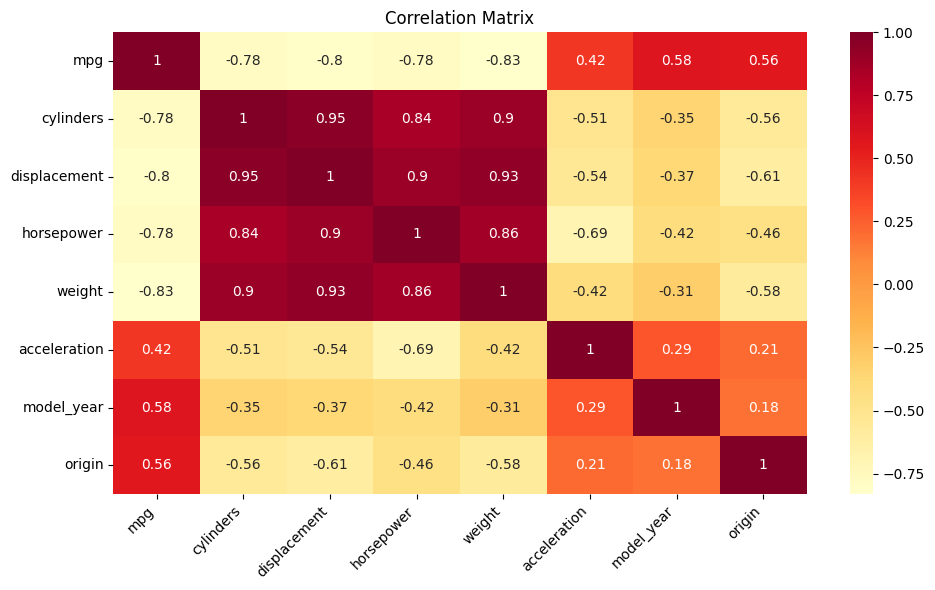

In [28]:
# Correlation Analysis
columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']
correlation_matrix = data[columns].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="YlOrRd")
plt.xticks(rotation=45, ha="right")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(results_dir + "correlation_analysis.png", dpi=400)
plt.show()

In [29]:
# Setup 
origin_map = {1: "USA", 2: "Europe", 3: "Japan"}
data["origin_label"] = data["origin"].map(origin_map)
numeric_cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]

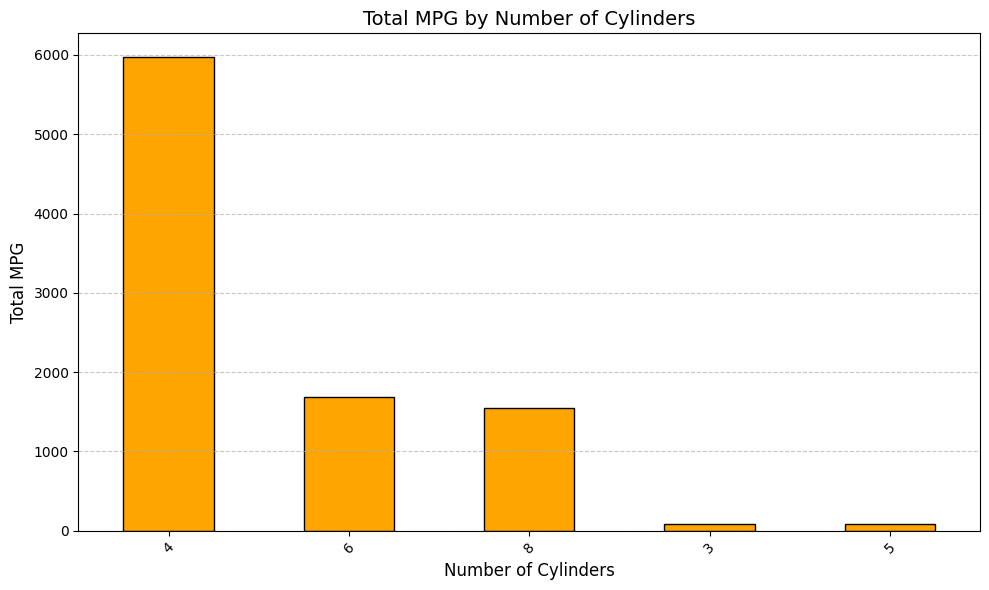

In [30]:
# Total MPG by Cylinders
total_mpg = data.groupby("cylinders")["mpg"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
total_mpg.plot(kind='bar', color='Orange', edgecolor='black')
plt.title("Total MPG by Number of Cylinders", fontsize=14)
plt.xlabel("Number of Cylinders", fontsize=12)
plt.ylabel("Total MPG", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "01_total_mpg_by_cylinders.png", dpi=400)
plt.show()

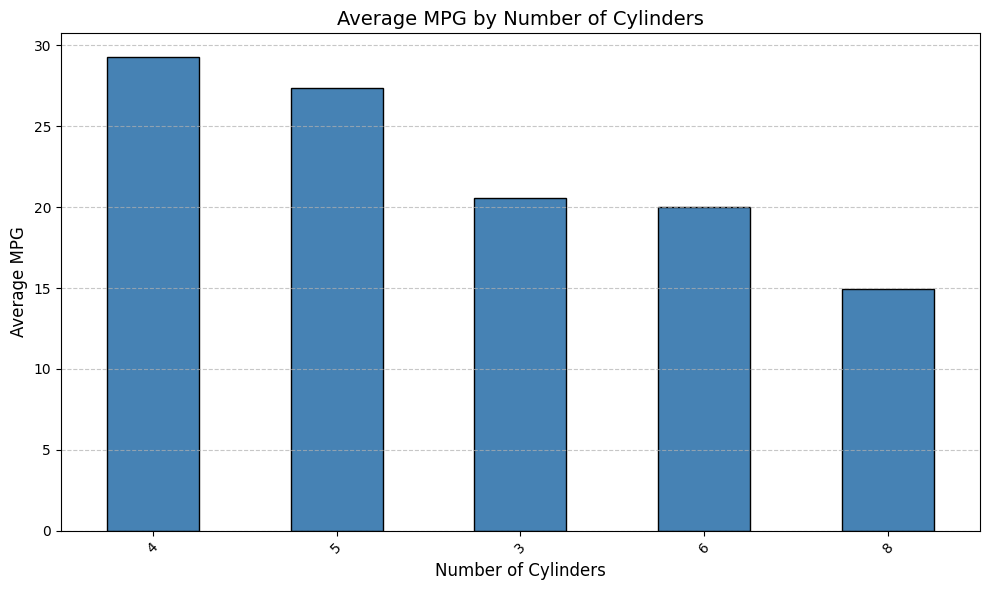

In [31]:
# Average MPG by Cylinders
avg_mpg = data.groupby("cylinders")["mpg"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
avg_mpg.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Average MPG by Number of Cylinders", fontsize=14)
plt.xlabel("Number of Cylinders", fontsize=12)
plt.ylabel("Average MPG", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "02_avg_mpg_by_cylinders.png", dpi=400)
plt.show()

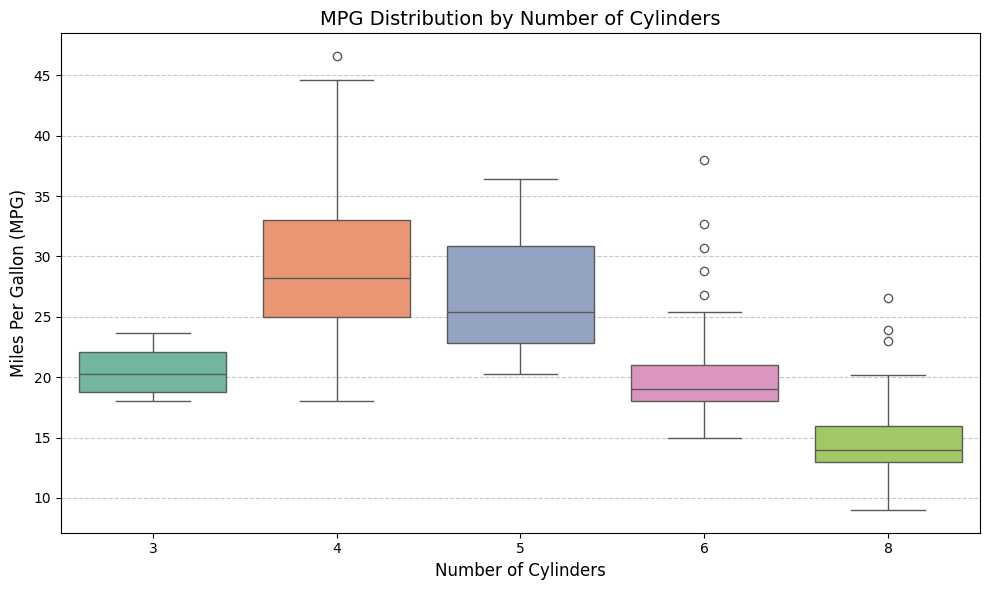

In [32]:
# Box Plot – MPG by Cylinders
plt.figure(figsize=(10, 6))
sns.boxplot(x="cylinders", y="mpg", data=data, palette="Set2")
plt.title("MPG Distribution by Number of Cylinders", fontsize=14)
plt.xlabel("Number of Cylinders", fontsize=12)
plt.ylabel("Miles Per Gallon (MPG)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "03_boxplot_mpg_cylinders.png", dpi=400)
plt.show()

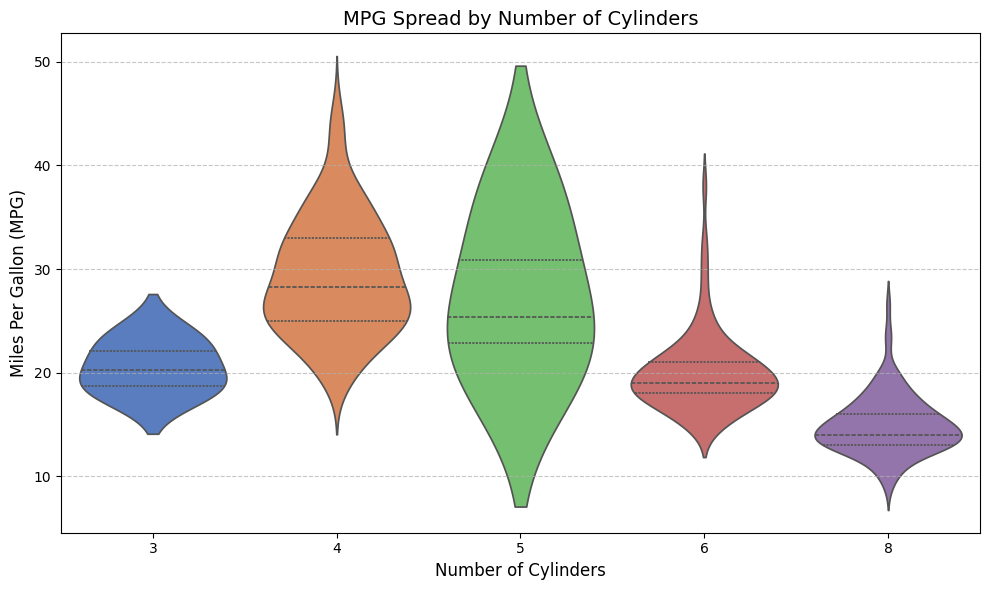

In [33]:
# Violin Plot – MPG by Cylinders
plt.figure(figsize=(10, 6))
sns.violinplot(x="cylinders", y="mpg", data=data, palette="muted", inner="quartile")
plt.title("MPG Spread by Number of Cylinders", fontsize=14)
plt.xlabel("Number of Cylinders", fontsize=12)
plt.ylabel("Miles Per Gallon (MPG)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "04_violin_mpg_cylinders.png", dpi=400)
plt.show()

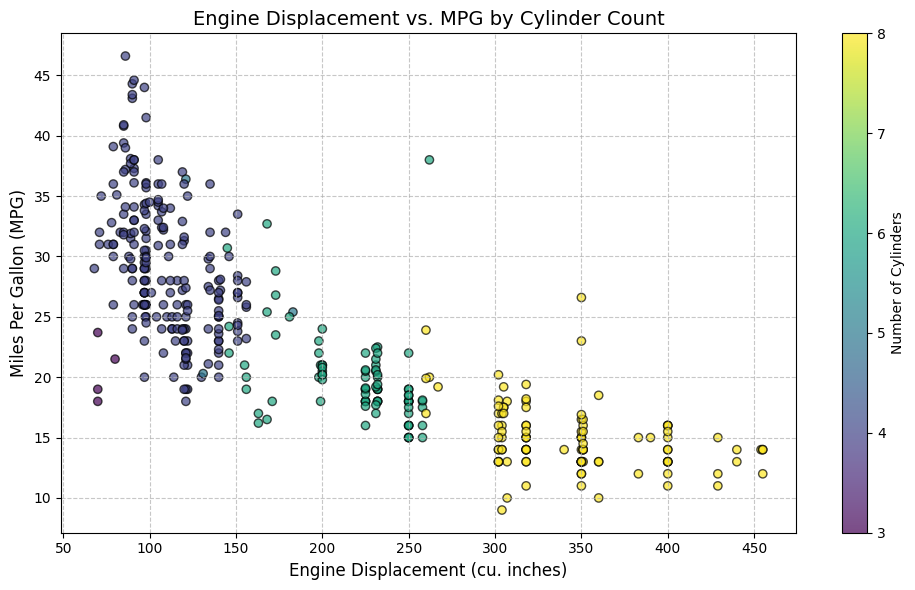

In [34]:
# Scatter – Displacement vs MPG coloured by Cylinders
plt.figure(figsize=(10, 6))
scatter = plt.scatter(data["displacement"], data["mpg"],
                      c=data["cylinders"], cmap="viridis", alpha=0.7, edgecolors='black')
plt.colorbar(scatter, label="Number of Cylinders")
plt.title("Engine Displacement vs. MPG by Cylinder Count", fontsize=14)
plt.xlabel("Engine Displacement (cu. inches)", fontsize=12)
plt.ylabel("Miles Per Gallon (MPG)", fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "05_displacement_vs_mpg.png", dpi=400)
plt.show()

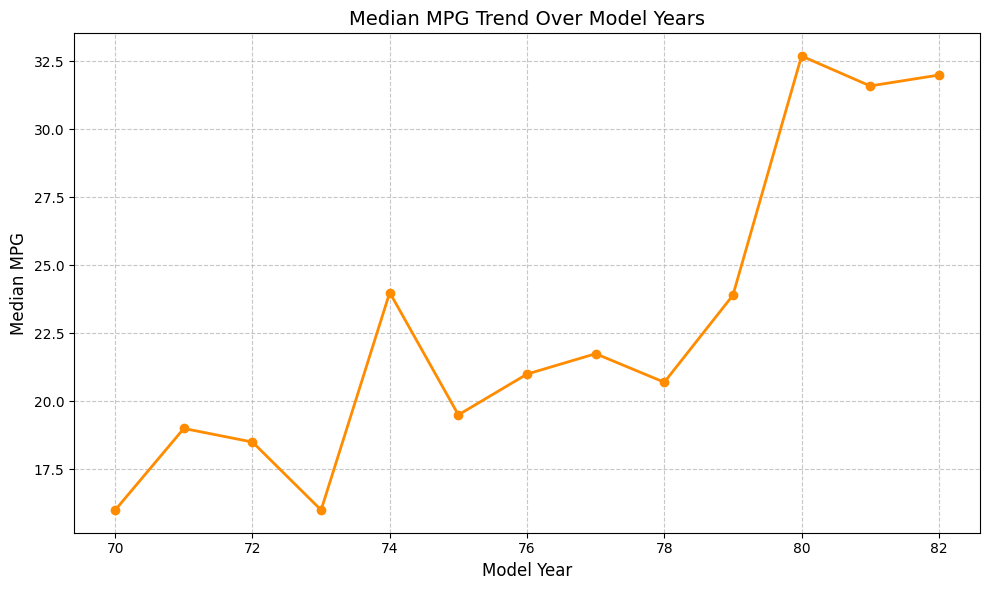

In [35]:
# Line – Median MPG Trend by Model Year
median_mpg_year = data.groupby("model_year")["mpg"].median()
plt.figure(figsize=(10, 6))
plt.plot(median_mpg_year.index, median_mpg_year.values, marker='o', color='darkorange', linewidth=2)
plt.title("Median MPG Trend Over Model Years", fontsize=14)
plt.xlabel("Model Year", fontsize=12)
plt.ylabel("Median MPG", fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "06_mpg_trend_by_year.png", dpi=400)
plt.show()

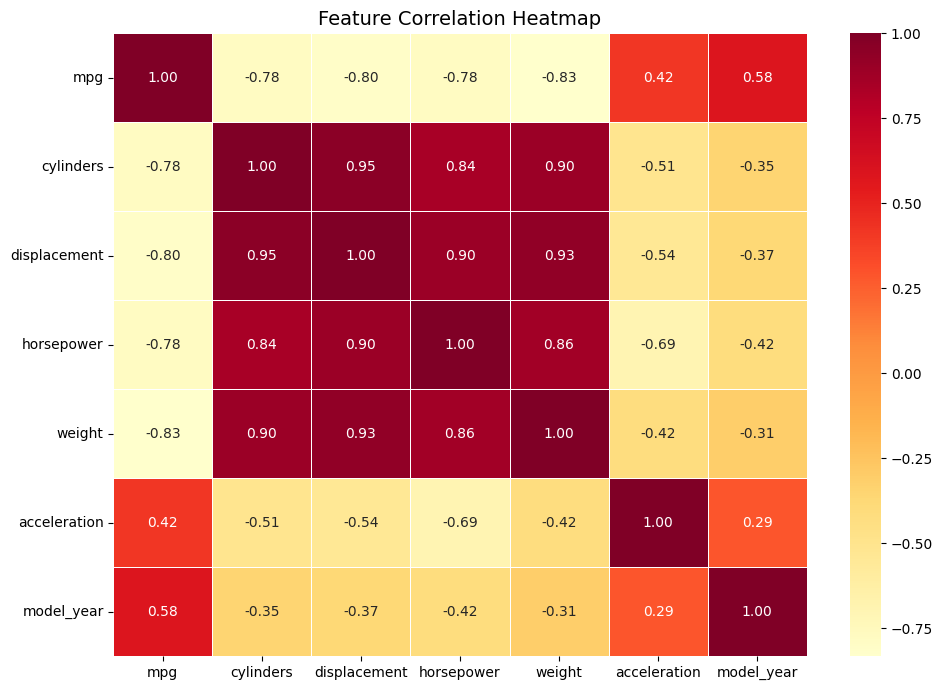

In [36]:
# Heatmap – Correlation Matrix
plt.figure(figsize=(10, 7))
corr = data[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig(results_dir + "07_correlation_heatmap.png", dpi=400)
plt.show()

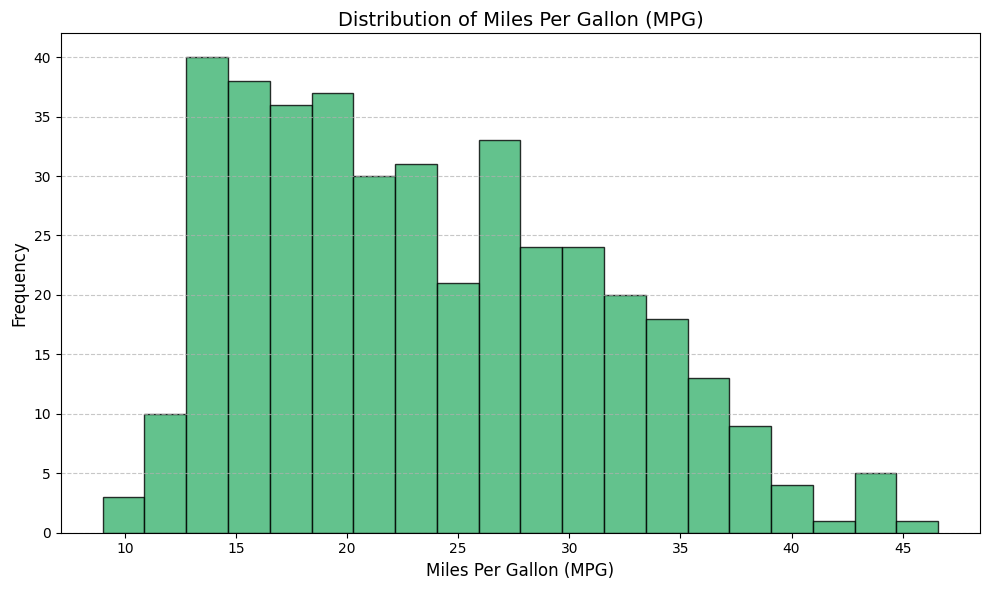

In [37]:
# Histogram – MPG Distribution
plt.figure(figsize=(10, 6))
plt.hist(data["mpg"], bins=20, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.title("Distribution of Miles Per Gallon (MPG)", fontsize=14)
plt.xlabel("Miles Per Gallon (MPG)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "08_mpg_histogram.png", dpi=400)
plt.show()

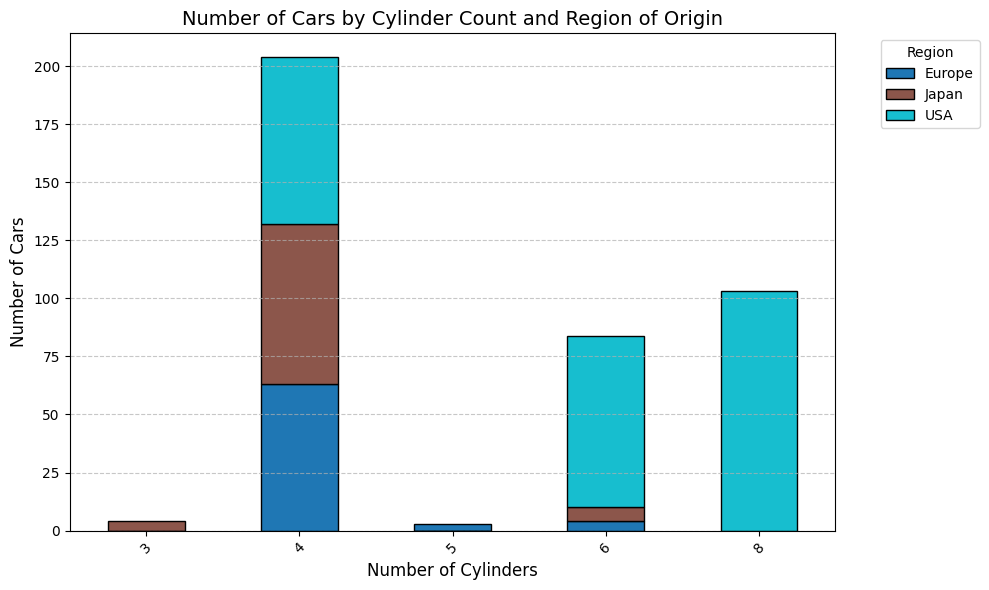

In [38]:
# Stacked Bar – Cars by Cylinders and Origin
pivot = data.groupby(["cylinders", "origin_label"]).size().unstack(fill_value=0)
pivot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10', edgecolor='black')
plt.title("Number of Cars by Cylinder Count and Region of Origin", fontsize=14)
plt.xlabel("Number of Cylinders", fontsize=12)
plt.ylabel("Number of Cars", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "09_cars_cylinders_origin.png", dpi=400)
plt.show()

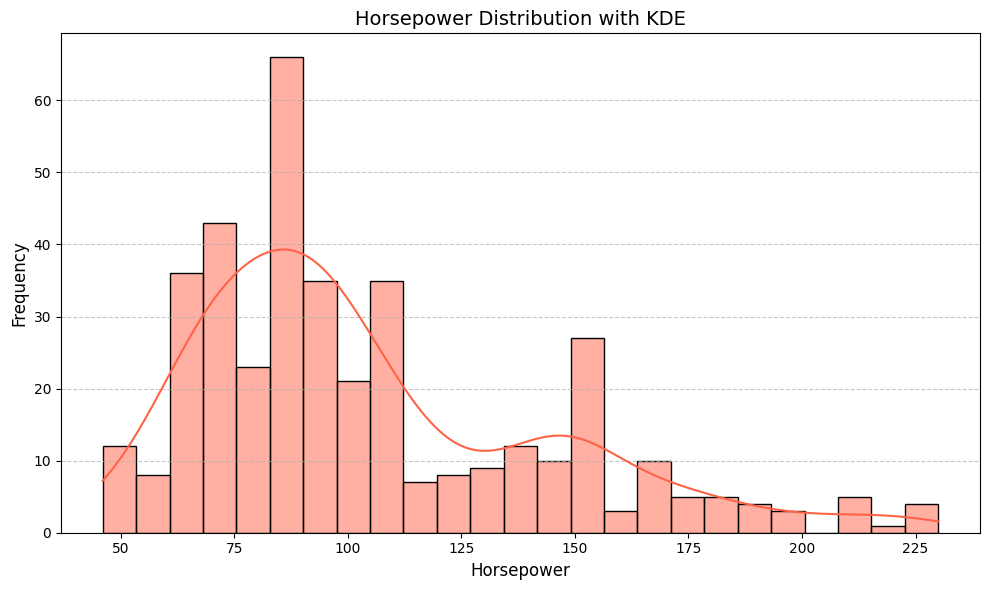

In [39]:
# Histogram with KDE – Horsepower Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data["horsepower"].dropna(), kde=True, color='tomato', bins=25)
plt.title("Horsepower Distribution with KDE", fontsize=14)
plt.xlabel("Horsepower", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "10_horsepower_kde.png", dpi=400)
plt.show()

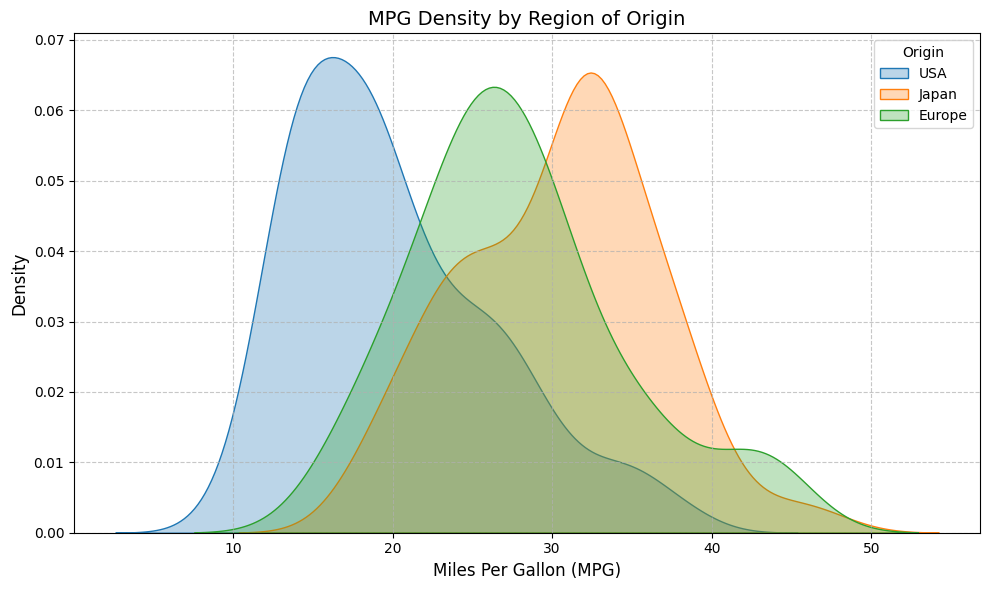

In [40]:
# KDE – MPG by Origin
plt.figure(figsize=(10, 6))
for origin in data["origin_label"].unique():
    subset = data[data["origin_label"] == origin]["mpg"]
    sns.kdeplot(subset, label=origin, fill=True, alpha=0.3)
plt.title("MPG Density by Region of Origin", fontsize=14)
plt.xlabel("Miles Per Gallon (MPG)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(title="Origin")
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "11_kde_mpg_by_origin.png", dpi=400)
plt.show()

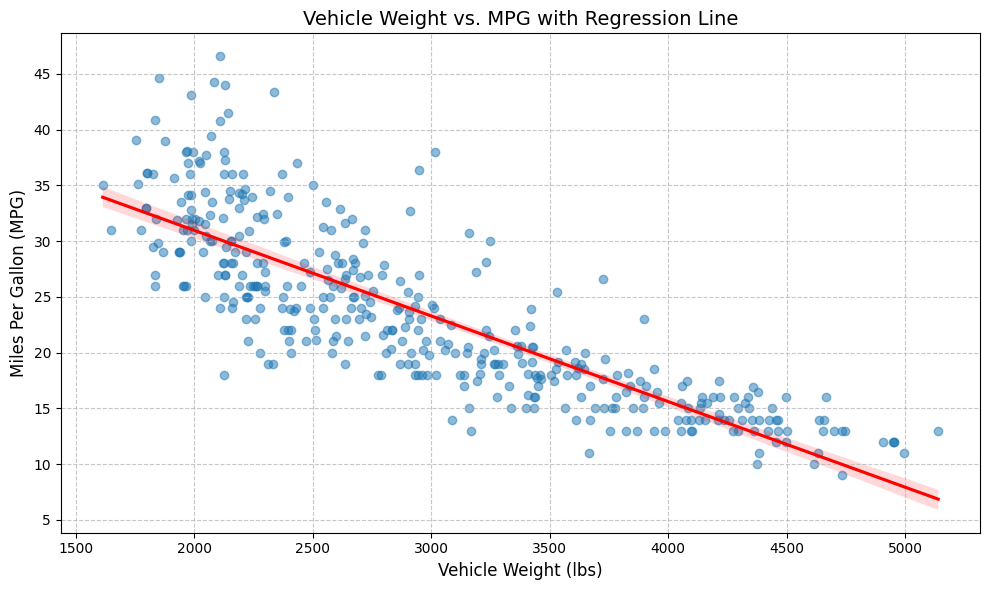

In [41]:
# Regression Plot – Weight vs MPG
plt.figure(figsize=(10, 6))
sns.regplot(x="weight", y="mpg", data=data, scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
plt.title("Vehicle Weight vs. MPG with Regression Line", fontsize=14)
plt.xlabel("Vehicle Weight (lbs)", fontsize=12)
plt.ylabel("Miles Per Gallon (MPG)", fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "12_weight_vs_mpg_regression.png", dpi=400)
plt.show()

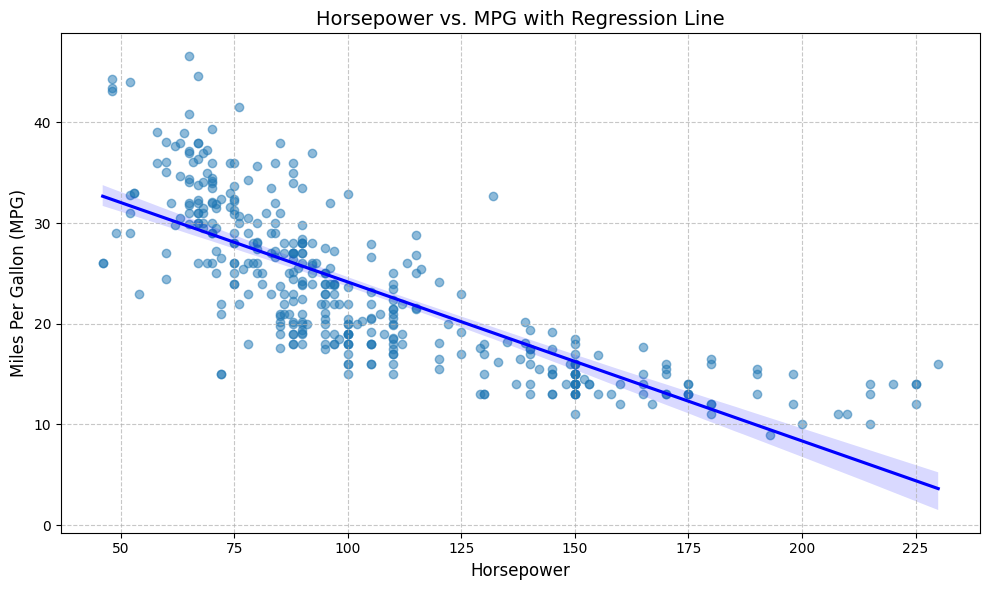

In [42]:
# Regression Plot – Horsepower vs MPG
plt.figure(figsize=(10, 6))
sns.regplot(x="horsepower", y="mpg", data=data, scatter_kws={"alpha": 0.5}, line_kws={"color": "blue"})
plt.title("Horsepower vs. MPG with Regression Line", fontsize=14)
plt.xlabel("Horsepower", fontsize=12)
plt.ylabel("Miles Per Gallon (MPG)", fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "13_horsepower_vs_mpg_regression.png", dpi=400)
plt.show()

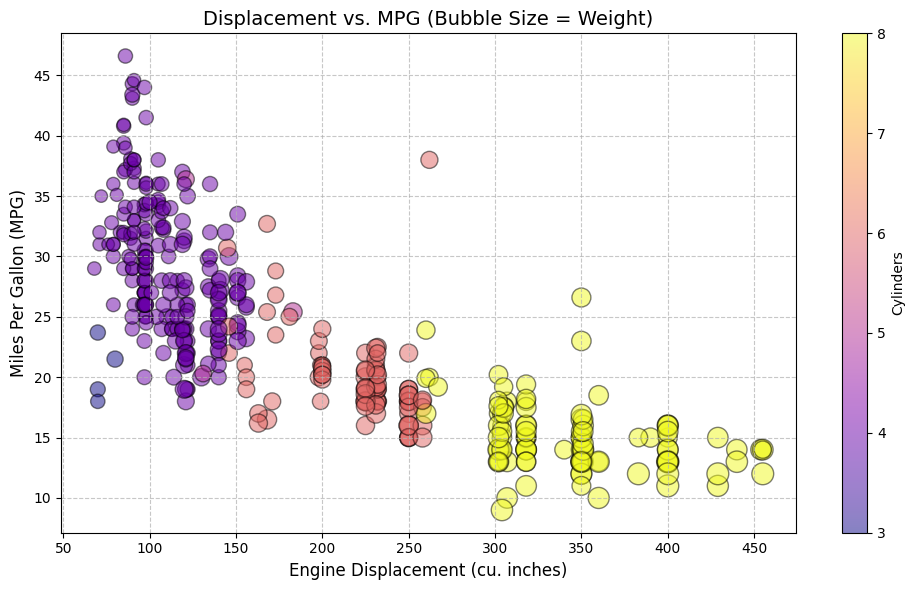

In [43]:
# Bubble Chart – Displacement vs MPG, size = Weight
plt.figure(figsize=(10, 6))
plt.scatter(data["displacement"], data["mpg"],
            s=data["weight"] / 20, alpha=0.5,
            c=data["cylinders"], cmap="plasma", edgecolors='black')
plt.colorbar(label="Cylinders")
plt.title("Displacement vs. MPG (Bubble Size = Weight)", fontsize=14)
plt.xlabel("Engine Displacement (cu. inches)", fontsize=12)
plt.ylabel("Miles Per Gallon (MPG)", fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "14_bubble_displacement_mpg_weight.png", dpi=400)
plt.show()

<Figure size 1000x600 with 0 Axes>

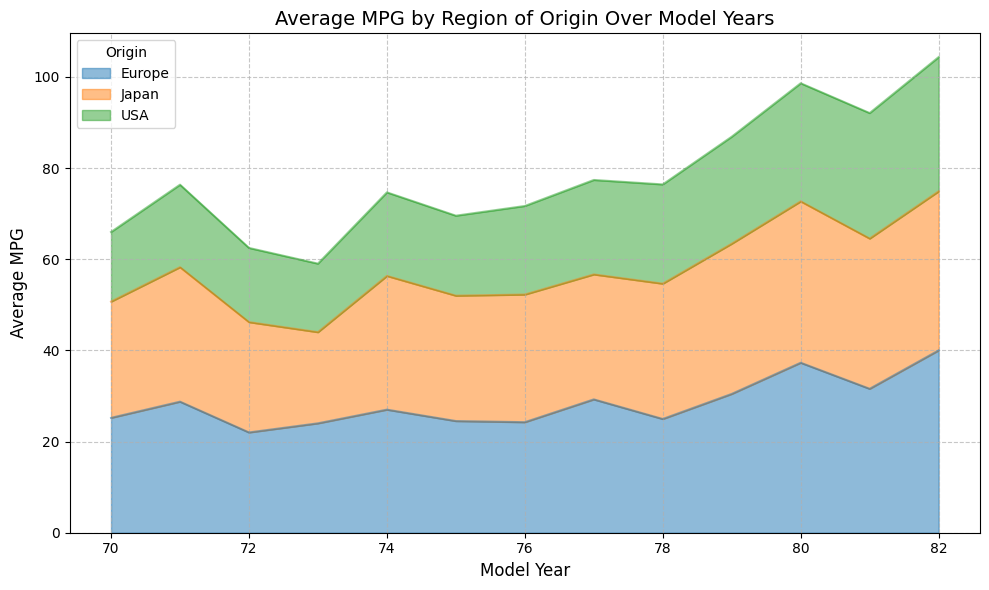

In [44]:
# Area Plot – Avg MPG by Origin over Model Year
area_data = data.groupby(["model_year", "origin_label"])["mpg"].mean().unstack()
plt.figure(figsize=(10, 6))
area_data.plot(kind='area', alpha=0.5, figsize=(10, 6))
plt.title("Average MPG by Region of Origin Over Model Years", fontsize=14)
plt.xlabel("Model Year", fontsize=12)
plt.ylabel("Average MPG", fontsize=12)
plt.legend(title="Origin")
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "15_area_mpg_origin_year.png", dpi=400)
plt.show()

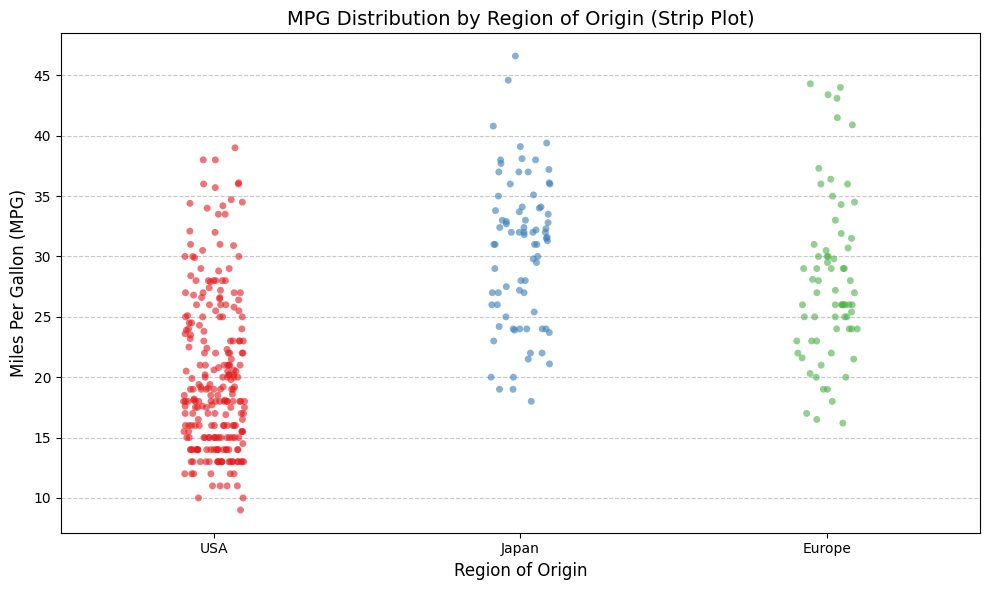

In [45]:
# Strip Plot – MPG by Origin
plt.figure(figsize=(10, 6))
sns.stripplot(x="origin_label", y="mpg", data=data, jitter=True, palette="Set1", alpha=0.6)
plt.title("MPG Distribution by Region of Origin (Strip Plot)", fontsize=14)
plt.xlabel("Region of Origin", fontsize=12)
plt.ylabel("Miles Per Gallon (MPG)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "16_strip_mpg_origin.png", dpi=400)
plt.show()

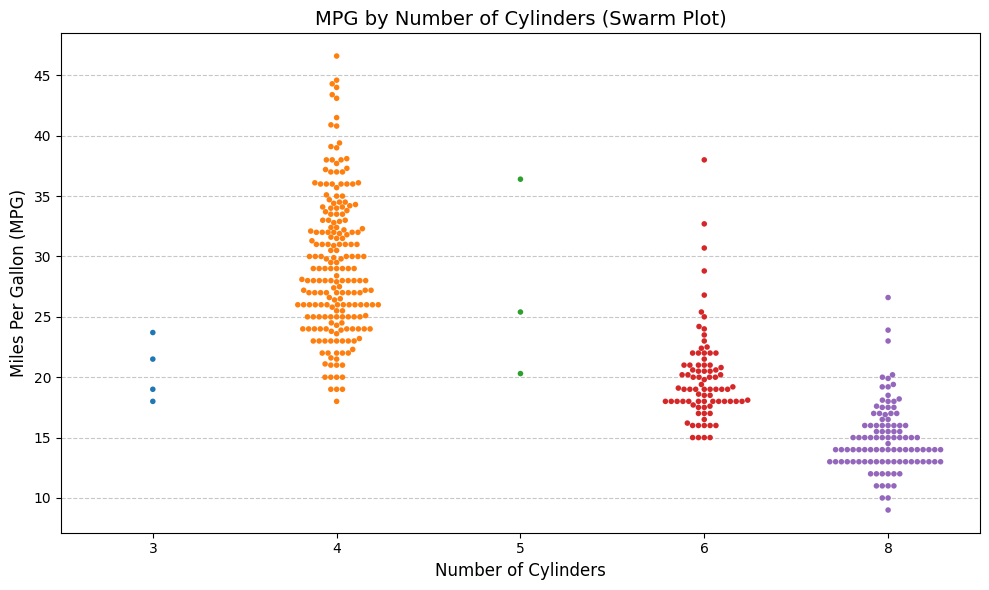

In [46]:
# Swarm Plot – MPG by Cylinders
plt.figure(figsize=(10, 6))
sns.swarmplot(x="cylinders", y="mpg", data=data, palette="tab10", size=4)
plt.title("MPG by Number of Cylinders (Swarm Plot)", fontsize=14)
plt.xlabel("Number of Cylinders", fontsize=12)
plt.ylabel("Miles Per Gallon (MPG)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "17_swarm_mpg_cylinders.png", dpi=400)
plt.show()

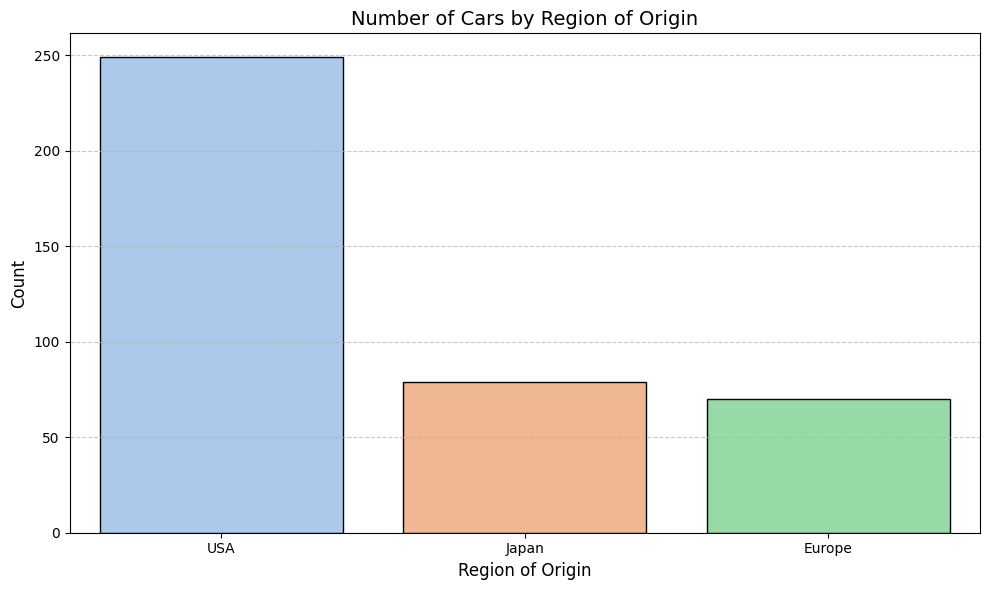

In [47]:
# Count Plot – Cars per Origin
plt.figure(figsize=(10, 6))
sns.countplot(x="origin_label", data=data, palette="pastel", edgecolor='black')
plt.title("Number of Cars by Region of Origin", fontsize=14)
plt.xlabel("Region of Origin", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "18_countplot_origin.png", dpi=400)
plt.show()

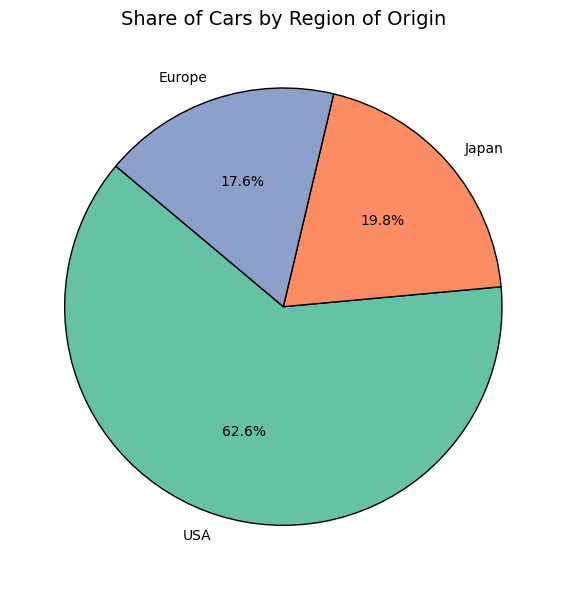

In [48]:
# Pie Chart – Share of Cars by Origin
origin_counts = data["origin_label"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(origin_counts, labels=origin_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette("Set2"), startangle=140, wedgeprops=dict(edgecolor='black'))
plt.title("Share of Cars by Region of Origin", fontsize=14)
plt.tight_layout()
plt.savefig(results_dir + "19_pie_origin.png", dpi=400)
plt.show()

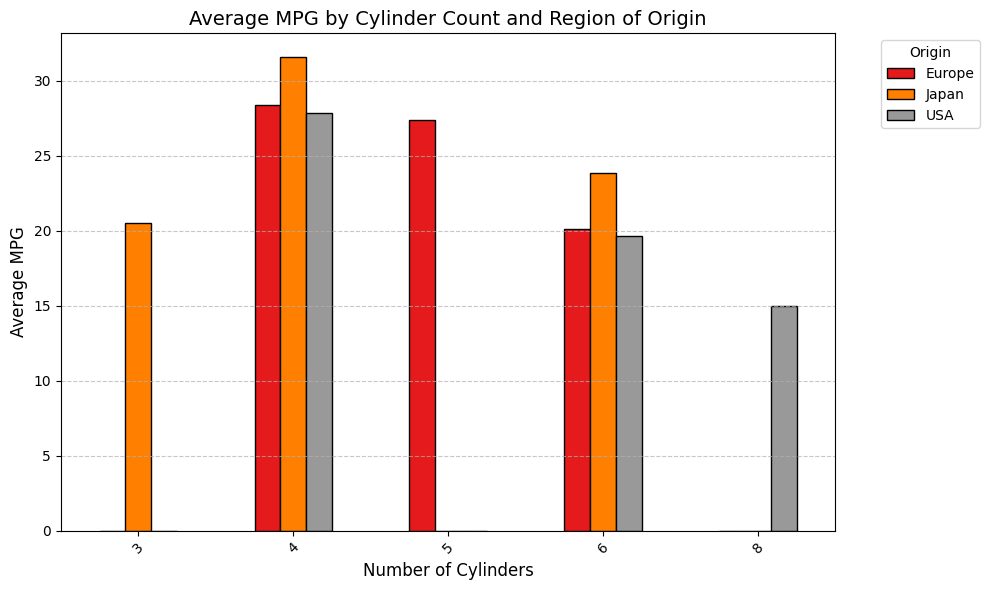

In [49]:
#Grouped Bar – Avg MPG by Cylinders and Origin
grouped = data.groupby(["cylinders", "origin_label"])["mpg"].mean().unstack()
grouped.plot(kind='bar', figsize=(10, 6), colormap='Set1', edgecolor='black')
plt.title("Average MPG by Cylinder Count and Region of Origin", fontsize=14)
plt.xlabel("Number of Cylinders", fontsize=12)
plt.ylabel("Average MPG", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Origin", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "20_grouped_bar_mpg_cylinders_origin.png", dpi=400)
plt.show()

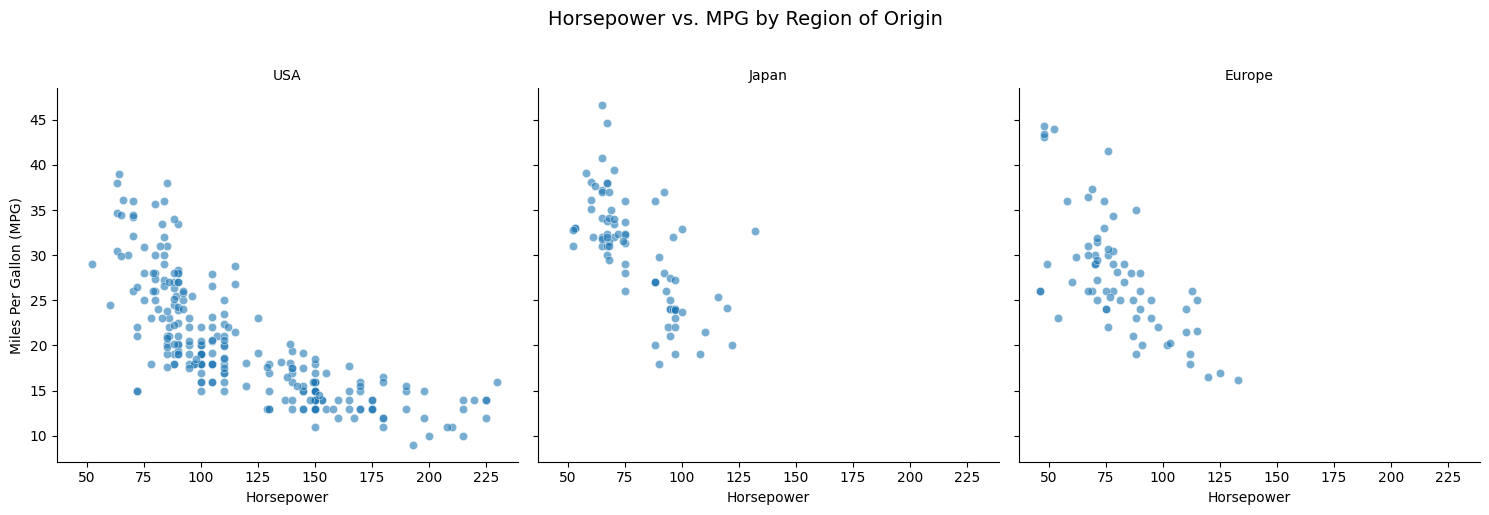

In [50]:
# Facet Grid – Horsepower vs MPG by Origin
g = sns.FacetGrid(data, col="origin_label", height=5, aspect=1)
g.map_dataframe(sns.scatterplot, x="horsepower", y="mpg", alpha=0.6)
g.set_axis_labels("Horsepower", "Miles Per Gallon (MPG)")
g.set_titles(col_template="{col_name}")
g.figure.suptitle("Horsepower vs. MPG by Region of Origin", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(results_dir + "21_facet_horsepower_mpg_origin.png", dpi=400, bbox_inches='tight')
plt.show()

In [51]:
# # Pair Plot – All Numeric Features coloured by Origin
# pair_data = data[["mpg", "displacement", "horsepower", "weight", "acceleration", "origin_label"]].dropna()
# g = sns.pairplot(pair_data, 
#                  kind="reg", 
#                  diag_kind="kde")
# g.figure.suptitle("Pair Plot of Key Features by Region of Origin", fontsize=14, y=1.01)
# plt.savefig(results_dir + "22_pairplot.png", dpi=400, bbox_inches='tight')
# plt.show()

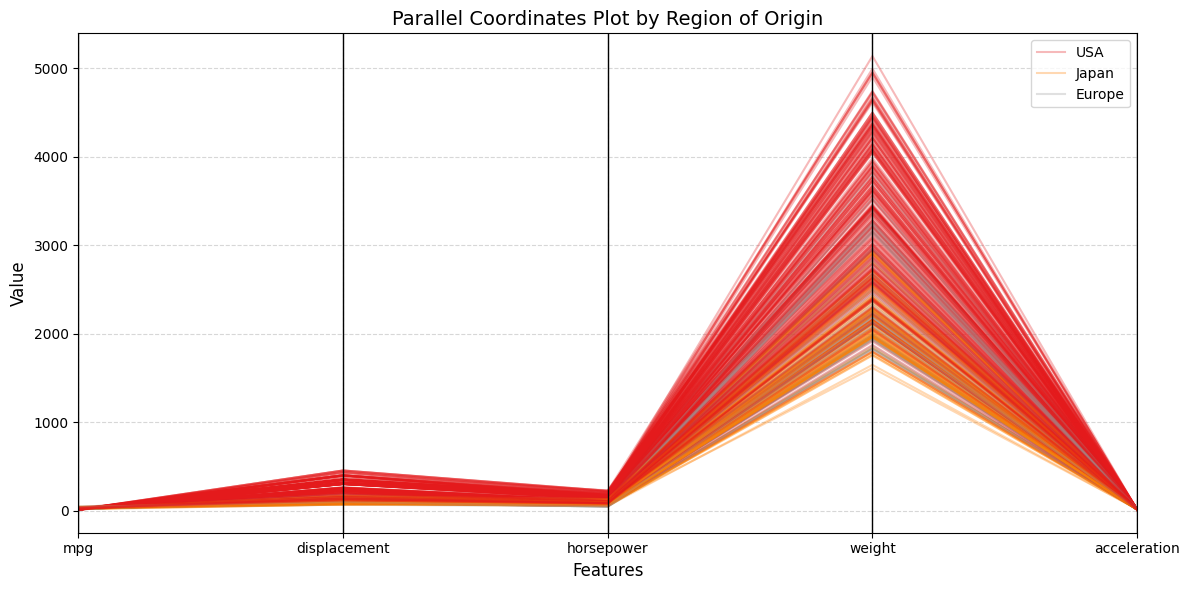

In [52]:
# Parallel Coordinates – Numeric Features by Origin
from pandas.plotting import parallel_coordinates

pc_data = data[["mpg", "displacement", "horsepower", "weight", "acceleration", "origin_label"]].dropna()
plt.figure(figsize=(12, 6))
parallel_coordinates(pc_data, class_column="origin_label", colormap="Set1", alpha=0.3)
plt.title("Parallel Coordinates Plot by Region of Origin", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(results_dir + "23_parallel_coordinates.png", dpi=400)
plt.show()

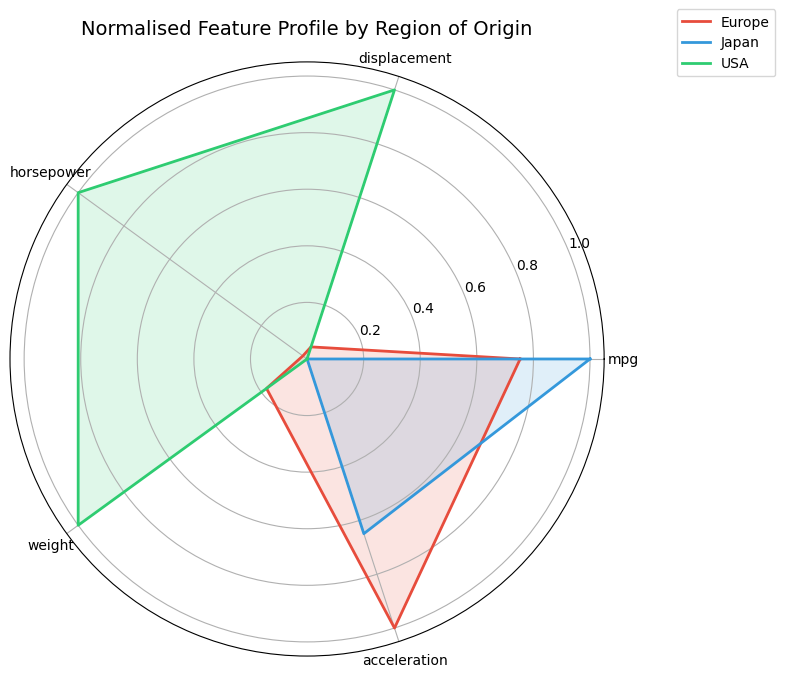

In [53]:
# Radar / Spider Chart – Avg Feature Profile by Origin
from matplotlib.patches import FancyBboxPatch

radar_cols = ["mpg", "displacement", "horsepower", "weight", "acceleration"]
radar_data = data.groupby("origin_label")[radar_cols].mean()
radar_data_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ["#e74c3c", "#3498db", "#2ecc71"]

for i, (origin, row) in enumerate(radar_data_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, label=origin, color=colors[i], linewidth=2)
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_cols)
ax.set_title("Normalised Feature Profile by Region of Origin", fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(results_dir + "24_radar_chart.png", dpi=400, bbox_inches='tight')
plt.show()

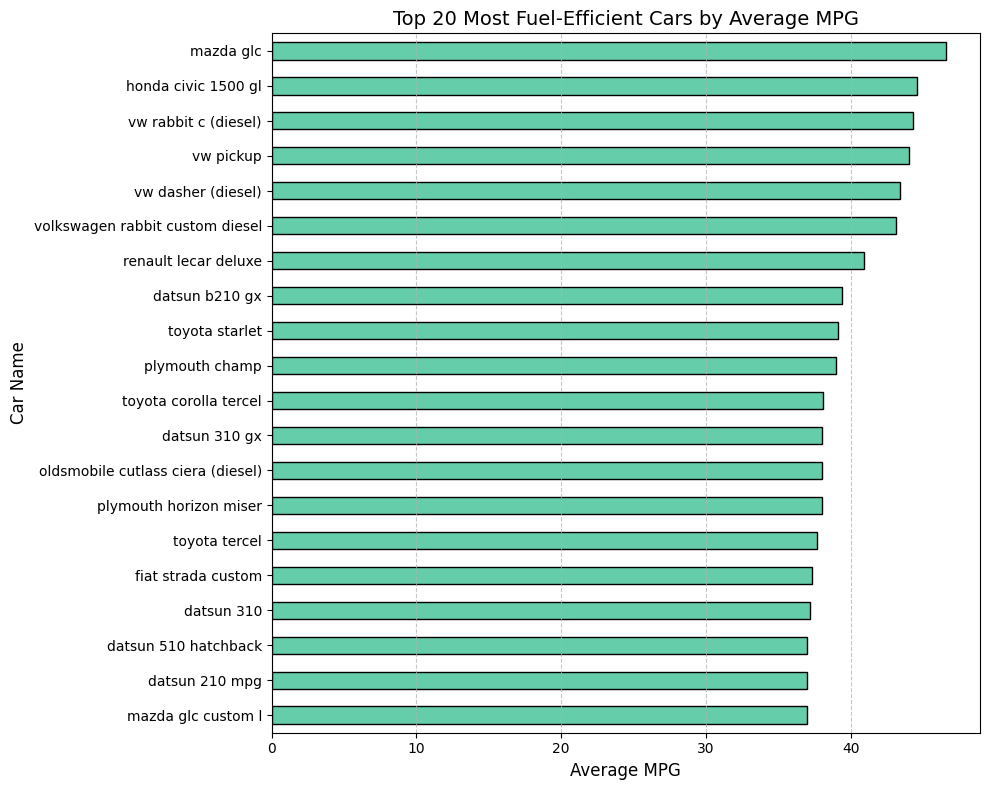

In [54]:
# Horizontal Bar – Top 20 Most Fuel-Efficient Cars
top20 = data.groupby("car_name")["mpg"].mean().nlargest(20).sort_values()
plt.figure(figsize=(10, 8))
top20.plot(kind='barh', color='mediumaquamarine', edgecolor='black')
plt.title("Top 20 Most Fuel-Efficient Cars by Average MPG", fontsize=14)
plt.xlabel("Average MPG", fontsize=12)
plt.ylabel("Car Name", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "25_top20_fuel_efficient.png", dpi=400)
plt.show()

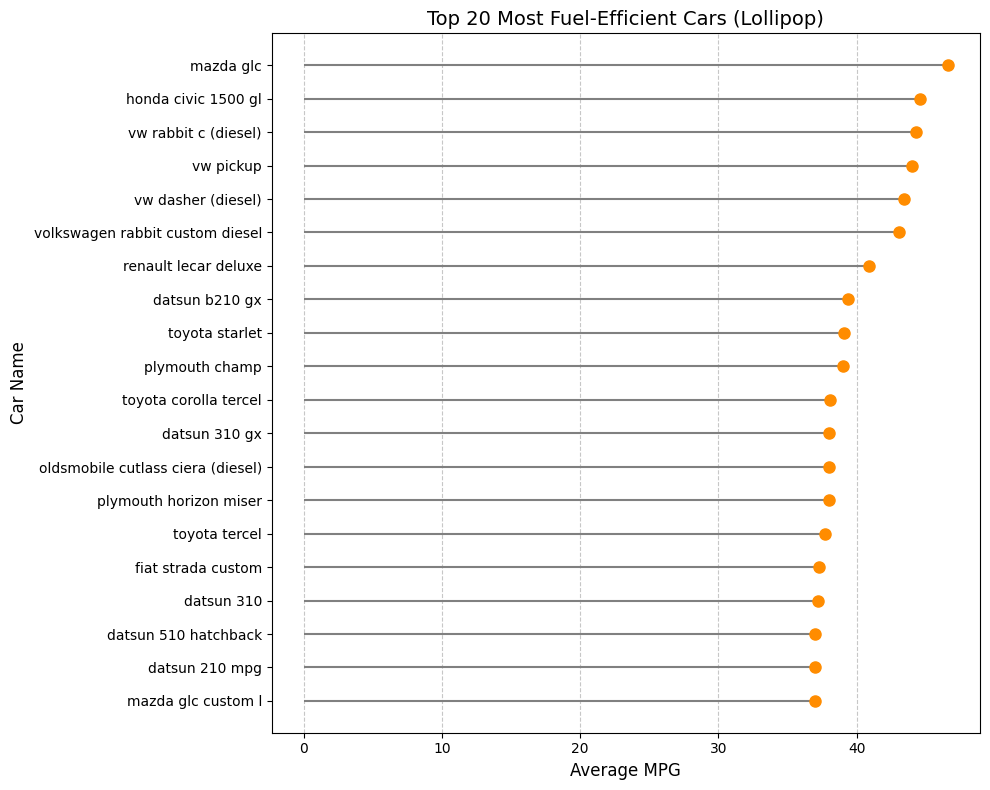

In [55]:
# Lollipop Chart – Top 20 Most Fuel-Efficient Cars
plt.figure(figsize=(10, 8))
plt.hlines(y=top20.index, xmin=0, xmax=top20.values, color='gray', linewidth=1.5)
plt.plot(top20.values, top20.index, "o", color='darkorange', markersize=8)
plt.title("Top 20 Most Fuel-Efficient Cars (Lollipop)", fontsize=14)
plt.xlabel("Average MPG", fontsize=12)
plt.ylabel("Car Name", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "26_lollipop_top20_mpg.png", dpi=400)
plt.show()


### Outlier Check

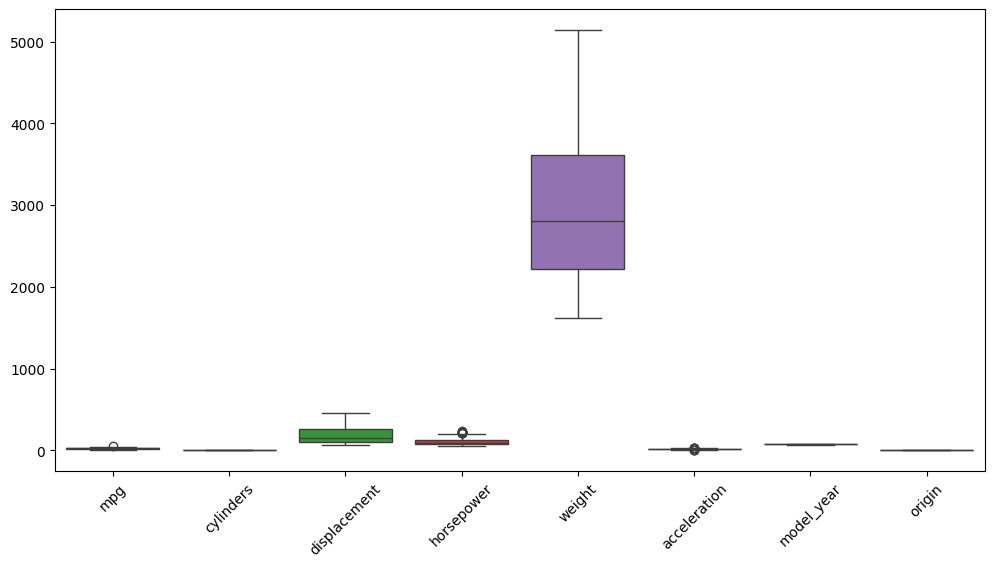

In [56]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.show()


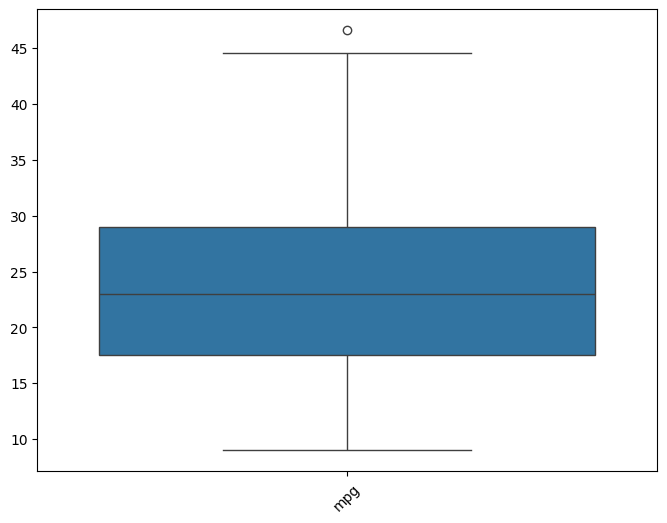

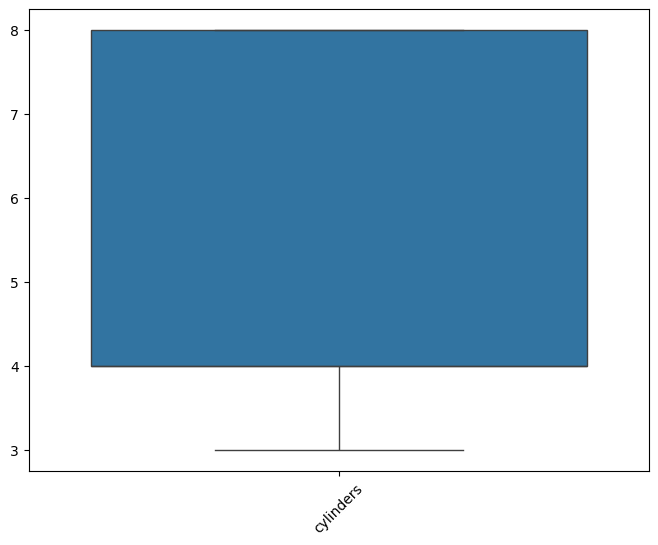

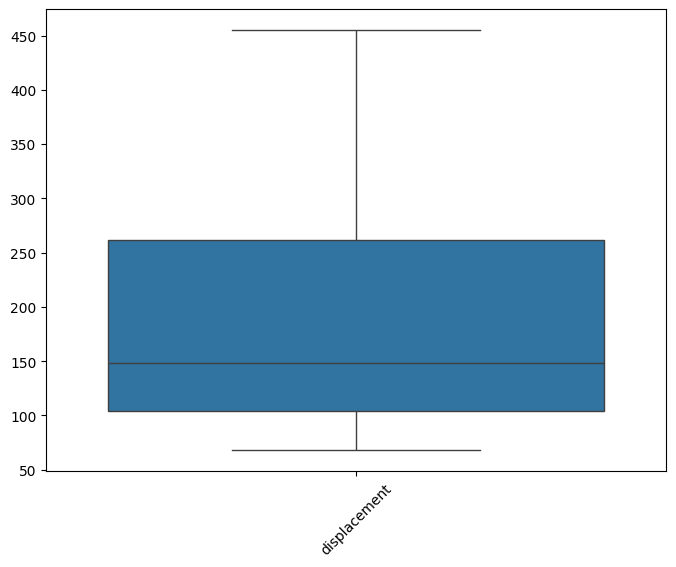

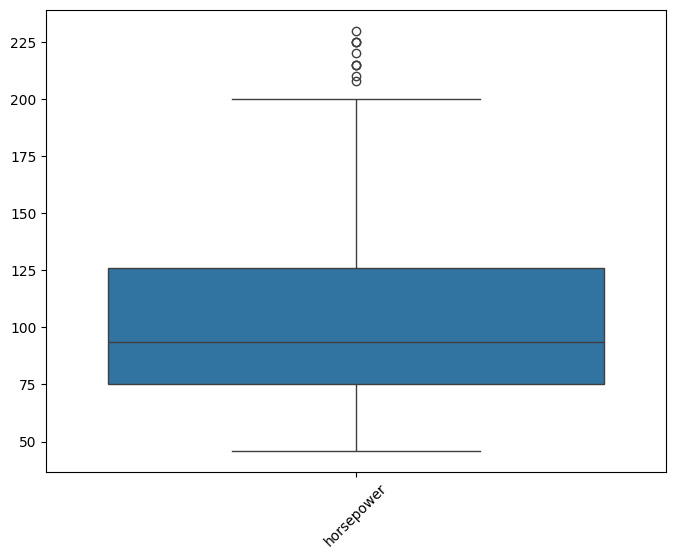

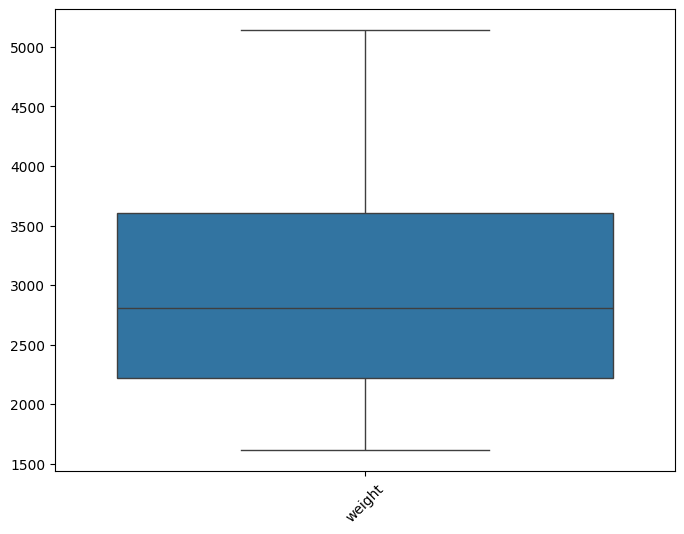

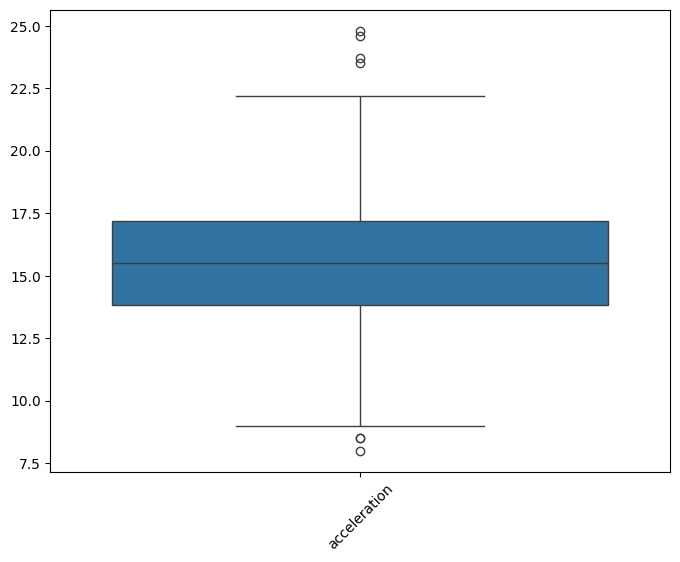

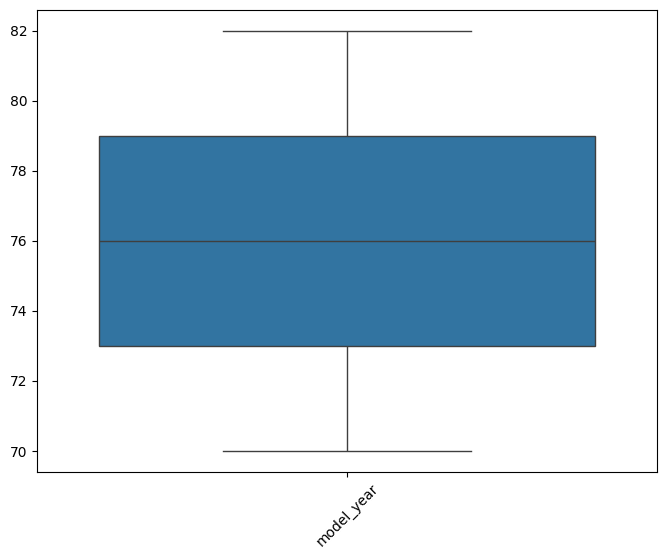

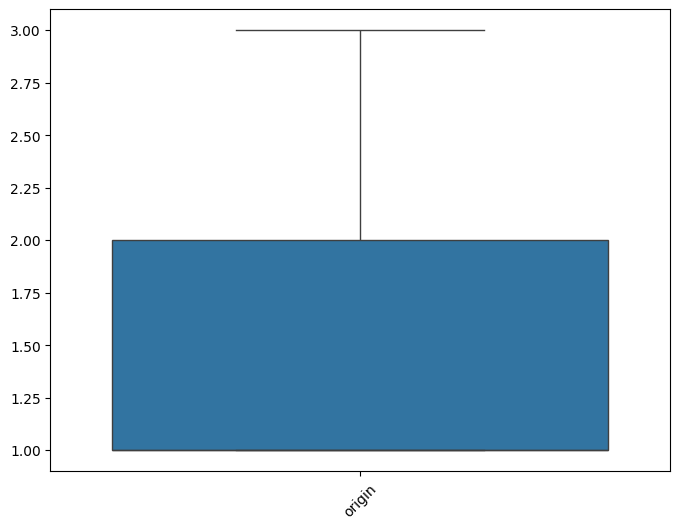

In [57]:
columns = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin"]


for column in columns:

    plt.figure(figsize=(8, 6))
    sns.boxplot(data=data[[column]])
    plt.xticks(rotation=45)
    plt.show()


### Handle Outliers in the `horsepower` and `weight` columns

In [58]:
def get_bounds(column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return lower, upper

hp_lower, hp_upper = get_bounds("horsepower")
acc_lower, acc_upper = get_bounds("acceleration")

print("Horsepower bounds:", hp_lower, hp_upper)
print("Acceleration bounds:", acc_lower, acc_upper)


Horsepower bounds: -1.5 202.5
Acceleration bounds: 8.8 22.2


### Handle Outliers (Capping)

In [59]:
data["horsepower"] = data["horsepower"].clip(hp_lower, hp_upper)
data["acceleration"] = data["acceleration"].clip(acc_lower, acc_upper)

In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
 9   origin_label  398 non-null    object 
dtypes: float64(5), int64(3), object(2)
memory usage: 31.2+ KB


### PyCaret Implementation

In [61]:
data = data.drop(["car_name", "origin_label"], axis=1)

In [62]:
from pycaret.regression import *

s = setup(data, target = 'mpg', session_id = 123)

,Description,Value
0,Session id,123
1,Target,mpg
2,Target type,Regression
3,Original data shape,"(398, 8)"
4,Transformed data shape,"(398, 8)"
5,Transformed train set shape,"(278, 8)"
6,Transformed test set shape,"(120, 8)"
7,Numeric features,7
8,Rows with missing values,1.5%
9,Preprocess,True


In [63]:
# compare baseline models
best = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,1.8815,6.9818,2.5935,0.8853,0.1008,0.0820,0.5480
catboost,CatBoost Regressor,1.8823,7.0245,2.6106,0.8833,0.1007,0.0817,0.3290
et,Extra Trees Regressor,1.8869,7.2509,2.6689,0.8773,0.1014,0.0814,0.0220
rf,Random Forest Regressor,1.9723,7.6832,2.7282,0.8728,0.1055,0.0864,0.0270
gbr,Gradient Boosting Regressor,2.0258,8.6895,2.8710,0.8582,0.1098,0.0879,0.0130
xgboost,Extreme Gradient Boosting,2.1385,9.0876,2.9559,0.8518,0.1120,0.0925,0.0400
ada,AdaBoost Regressor,2.2714,10.1970,3.1435,0.8324,0.1208,0.0997,0.0140
ridge,Ridge Regression,2.5350,11.4815,3.3479,0.8117,0.1459,0.1175,0.0060
lr,Linear Regression,2.5359,11.4837,3.3482,0.8116,0.1458,0.1175,0.3100
br,Bayesian Ridge,2.5240,11.5169,3.3536,0.8110,0.1477,0.1175,0.0060


In [64]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [65]:
data.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [66]:
data["horsepower"]= data["horsepower"].fillna(data["horsepower"].mean())
data.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [67]:
# Separating predictors from target
X = data.drop(["mpg"], axis=1)
y = data["mpg"]

# Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, 
)

In [68]:
X_train

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
232,8,351.0,149.000000,4335.0,14.5,77,1
237,4,98.0,63.000000,2051.0,17.0,77,1
6,8,454.0,202.500000,4354.0,9.0,70,1
220,4,85.0,70.000000,1945.0,16.8,77,3
336,4,140.0,104.053571,2905.0,14.3,80,1
...,...,...,...,...,...,...,...
230,8,350.0,170.000000,4165.0,11.4,77,1
98,6,250.0,100.000000,3278.0,18.0,73,1
322,4,86.0,65.000000,2110.0,17.9,80,3
382,4,108.0,70.000000,2245.0,16.9,82,3


In [69]:
X_test

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
150,4,108.0,93.0,2391.0,15.5,74,3
42,8,383.0,180.0,4955.0,11.5,71,1
120,4,121.0,112.0,2868.0,15.5,73,2
102,4,97.0,46.0,1950.0,21.0,73,2
293,4,89.0,71.0,1925.0,14.0,79,2
...,...,...,...,...,...,...,...
217,4,111.0,80.0,2155.0,14.8,77,1
201,6,250.0,110.0,3645.0,16.2,76,1
366,6,225.0,85.0,3465.0,16.6,81,1
134,6,258.0,110.0,3632.0,18.0,74,1


### After scaling

In [70]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [71]:
# Define models
models = {
    "LightGBM": LGBMRegressor(device='gpu', verbose=1),
    "CatBoost": CatBoostRegressor(task_type="GPU", verbose=100),
    "ExtraTrees": ExtraTreesRegressor(),
    "RandomForest": RandomForestRegressor()
}
# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 280
[LightGBM] [Info] Number of data points in the train set: 318, number of used features: 7
[LightGBM] [Info] Using GPU Device: Quadro RTX 4000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 7 dense feature groups (0.00 MB) transferred to GPU in 0.000645 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 23.412579
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [72]:
for key, result in results.items():
    print(f"{key}: {result}")

LightGBM: {'MAE': 2.037130576706273, 'MSE': 9.341090522675703, 'RMSE': 3.056319767739577, 'R2': 0.8398457877385624}
CatBoost: {'MAE': 2.1021041963007105, 'MSE': 9.316134303334236, 'RMSE': 3.0522343133079146, 'R2': 0.8402736653659073}
ExtraTrees: {'MAE': 2.0912875, 'MSE': 9.987982012499993, 'RMSE': 3.160376878237783, 'R2': 0.828754748986723}
RandomForest: {'MAE': 2.1315375000000003, 'MSE': 10.112323587500004, 'RMSE': 3.179987985433279, 'R2': 0.8266228965068512}


In [73]:
# Ensemble: Averaging
ensemble1 = VotingRegressor([
    ('lgbm', models["LightGBM"]),
    ('catboost', models["CatBoost"]),
    ('extra_trees', models["ExtraTrees"]),
    ('rf', models["RandomForest"]),
])

In [74]:
# Example: train and evaluate
ensemble1.fit(X_train, y_train)
y_pred = ensemble1.predict(X_test)

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 280
[LightGBM] [Info] Number of data points in the train set: 318, number of used features: 7
[LightGBM] [Info] Using GPU Device: Quadro RTX 4000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 7 dense feature groups (0.00 MB) transferred to GPU in 0.000250 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 23.412579
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [75]:
# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Ensemble1 R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

Ensemble1 R²: 0.8416
MAE: 2.0641
MSE: 9.2365
RMSE: 3.0392


### RandomSearchCV

In [76]:
# Tune each model SEPARATELY (not inside VotingRegressor)
print("=" * 60)
print("PHASE 1: Individual Model Tuning")
print("=" * 60)

# LightGBM (GPU)
print("\nTuning LightGBM on GPU...")
lgbm_params = {
    'n_estimators':      randint(200, 1000),
    'learning_rate':     uniform(0.01, 0.15),
    'max_depth':         randint(4, 12),
    'num_leaves':        randint(20, 150),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'min_child_samples': randint(10, 50),
    'reg_alpha':         uniform(0, 1),
    'reg_lambda':        uniform(0, 1),
}

lgbm_search = RandomizedSearchCV(
    LGBMRegressor(device='gpu', n_jobs=1, verbose=-1),  # GPU handles parallelism
    lgbm_params,
    n_iter=40,           # not 100s — 40 is enough with RandomizedSearch
    cv=5,
    scoring='r2',
    verbose=0,
    n_jobs=1,            # 1 job — GPU model, don't multiprocess
    random_state=42
)

with tqdm(total=1, desc="LightGBM Search") as pbar:
    lgbm_search.fit(X_train, y_train)
    pbar.update(1)

best_lgbm = lgbm_search.best_estimator_
print(f" Best R²: {lgbm_search.best_score_:.4f}")
print(f"   Best params: {lgbm_search.best_params_}")


PHASE 1: Individual Model Tuning

Tuning LightGBM on GPU...


LightGBM Search:   0%|          | 0/1 [00:00<?, ?it/s]

 Best R²: 0.8782
   Best params: {'colsample_bytree': 0.9771638815650077, 'learning_rate': 0.058480439803113286, 'max_depth': 11, 'min_child_samples': 33, 'n_estimators': 432, 'num_leaves': 132, 'reg_alpha': 0.06489224710898156, 'reg_lambda': 0.2539154139343447, 'subsample': 0.6987504251354405}


In [77]:

# CatBoost (GPU)
print("\nTuning CatBoost on GPU...")
catboost_params = {
    'iterations':           randint(200, 800),
    'learning_rate':        uniform(0.01, 0.15),
    'depth':                randint(4, 10),
    'l2_leaf_reg':          uniform(1, 9),
    'bagging_temperature':  uniform(0, 5),
    'random_strength':      uniform(0, 5),
}

catboost_search = RandomizedSearchCV(
    CatBoostRegressor(task_type="GPU", verbose=0),
    catboost_params,
    n_iter=40,
    cv=5,
    scoring='r2',
    verbose=0,
    n_jobs=1,            # GPU model — don't multiprocess
    random_state=42
)

with tqdm(total=1, desc="CatBoost Search") as pbar:
    catboost_search.fit(X_train, y_train)
    pbar.update(1)

best_catboost = catboost_search.best_estimator_
print(f"   Best R²: {catboost_search.best_score_:.4f}")
print(f"   Best params: {catboost_search.best_params_}")


Tuning CatBoost on GPU...


CatBoost Search:   0%|          | 0/1 [00:00<?, ?it/s]

   Best R²: 0.8929
   Best params: {'bagging_temperature': 3.803925243084487, 'depth': 5, 'iterations': 702, 'l2_leaf_reg': 7.938704619591049, 'learning_rate': 0.08406933945465861, 'random_strength': 2.6136641469099704}


In [78]:
# ExtraTrees (ALL 12 CPU cores)
print("\nTuning ExtraTrees on all CPU cores...")
et_params = {
    'n_estimators':      randint(200, 800),
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf':  randint(1, 8),
    'max_features':      ['sqrt', 'log2', 0.5, 0.8],
}

et_search = RandomizedSearchCV(
    ExtraTreesRegressor(n_jobs=-1),   # uses all 12 cores
    et_params,
    n_iter=40,
    cv=5,
    scoring='r2',
    verbose=0,
    n_jobs=1,            # model already uses all cores internally
    random_state=42
)

with tqdm(total=1, desc="ExtraTrees Search") as pbar:
    et_search.fit(X_train, y_train)
    pbar.update(1)

best_et = et_search.best_estimator_
print(f"   Best R²: {et_search.best_score_:.4f}")
print(f"   Best params: {et_search.best_params_}")


Tuning ExtraTrees on all CPU cores...


ExtraTrees Search:   0%|          | 0/1 [00:00<?, ?it/s]

   Best R²: 0.8942
   Best params: {'max_depth': 30, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 684}


In [79]:
# RandomForest (ALL 12 CPU cores)
print("\nTuning RandomForest on all CPU cores...")
rf_params = {
    'n_estimators':      randint(200, 800),
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf':  randint(1, 8),
    'max_features':      ['sqrt', 'log2', 0.5, 0.8],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1),   # uses all 12 cores
    rf_params,
    n_iter=40,
    cv=5,
    scoring='r2',
    verbose=0,
    n_jobs=1,
    random_state=42
)

with tqdm(total=1, desc="RandomForest Search") as pbar:
    rf_search.fit(X_train, y_train)
    pbar.update(1)

best_rf = rf_search.best_estimator_
print(f"   Best R²: {rf_search.best_score_:.4f}")
print(f"   Best params: {rf_search.best_params_}")


Tuning RandomForest on all CPU cores...


RandomForest Search:   0%|          | 0/1 [00:00<?, ?it/s]

   Best R²: 0.8744
   Best params: {'max_depth': 30, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 684}


In [80]:
# Build ensemble from best tuned models
print("\n" + "=" * 60)
print("PHASE 2: Building & Evaluating Ensemble")
print("=" * 60)

ensemble2 = VotingRegressor([
    ('lgbm',        best_lgbm),
    ('catboost',    best_catboost),
    ('extra_trees', best_et),
    ('rf',          best_rf),
])

print("\nFitting ensemble on full training data...")
with tqdm(total=1, desc="Ensemble Fit") as pbar:
    ensemble2.fit(X_train, y_train)
    pbar.update(1)


PHASE 2: Building & Evaluating Ensemble

Fitting ensemble on full training data...


Ensemble Fit:   0%|          | 0/1 [00:00<?, ?it/s]

In [81]:
# Evaluate 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("\n" + "=" * 60)
print("PHASE 3: Results")
print("=" * 60)

models_to_eval = {
    "LightGBM":   best_lgbm,
    "CatBoost":   best_catboost,
    "ExtraTrees": best_et,
    "RandomForest": best_rf,
    "Ensemble":   ensemble2,
}

for name, model in tqdm(models_to_eval.items(), desc="Evaluating models"):
    preds = model.predict(X_test)
    r2  = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"  {name:<15} R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}")


PHASE 3: Results


Evaluating models:   0%|          | 0/5 [00:00<?, ?it/s]

  LightGBM        R²=0.8251  MAE=2.2135  RMSE=3.1938
  CatBoost        R²=0.8400  MAE=2.1325  RMSE=3.0545
  ExtraTrees      R²=0.8281  MAE=2.0974  RMSE=3.1664
  RandomForest    R²=0.8310  MAE=2.1219  RMSE=3.1393
  Ensemble        R²=0.8387  MAE=2.0829  RMSE=3.0668


### Model Evaluation

ensemble1 R²: 0.8416
ensemble1 MAE: 2.0641
ensemble1 MSE: 9.2365
ensemble1 RMSE: 3.0392


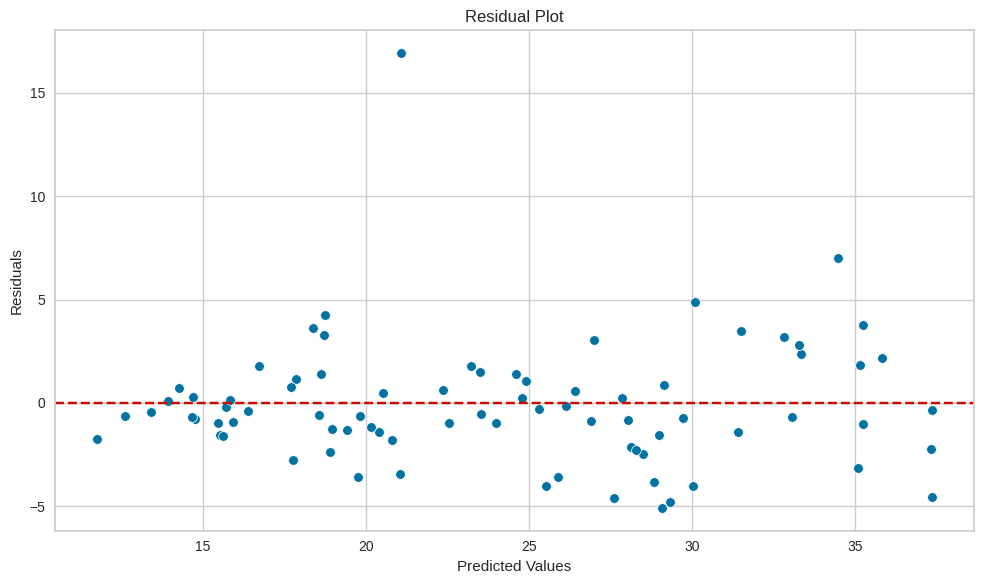

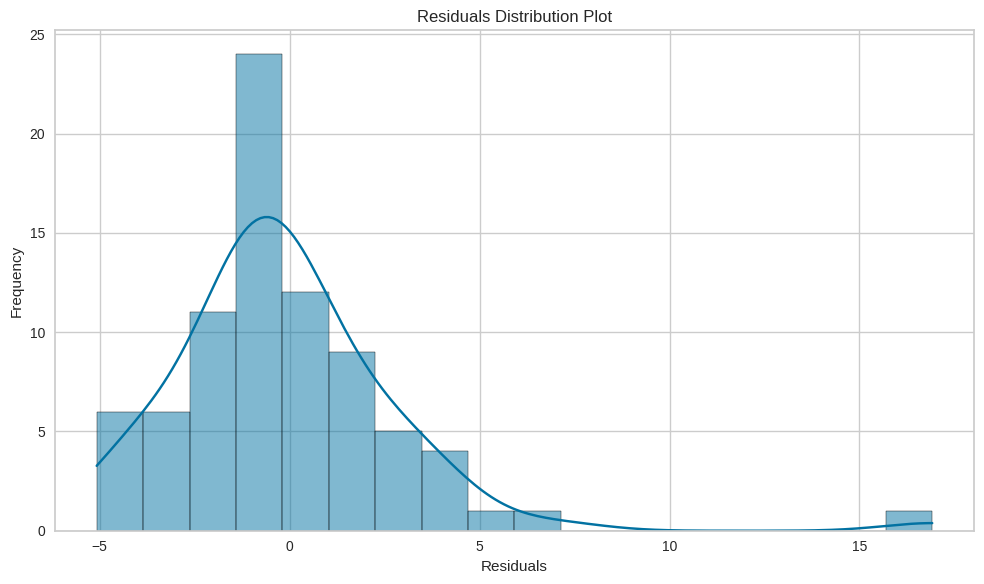

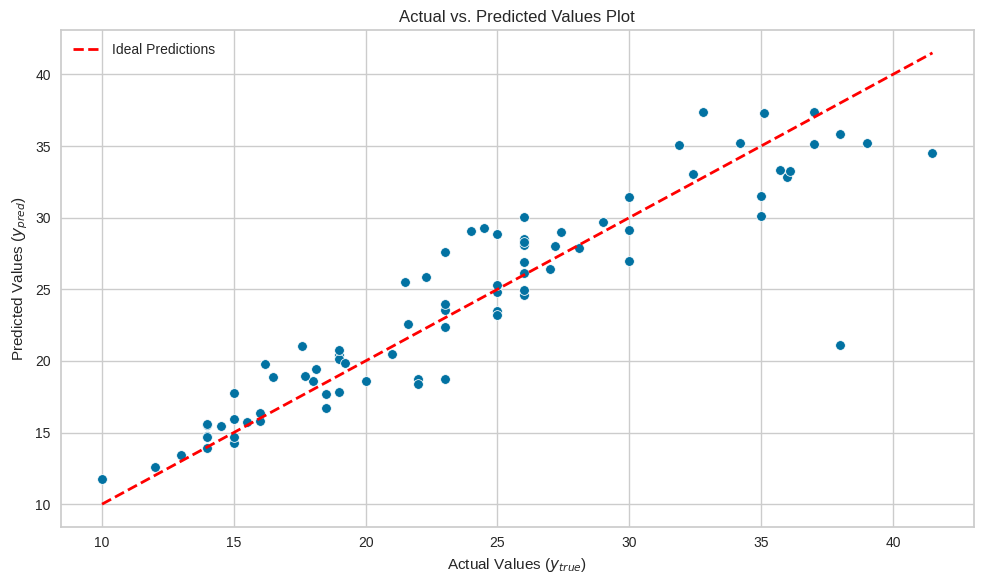

\ensemble1 model saved to best_ensemble1_model.pkl


In [82]:
model_evaluation(ensemble1, X_test, y_test, results_dir, name="ensemble1")

ensemble2 R²: 0.8387
ensemble2 MAE: 2.0829
ensemble2 MSE: 9.4055
ensemble2 RMSE: 3.0668


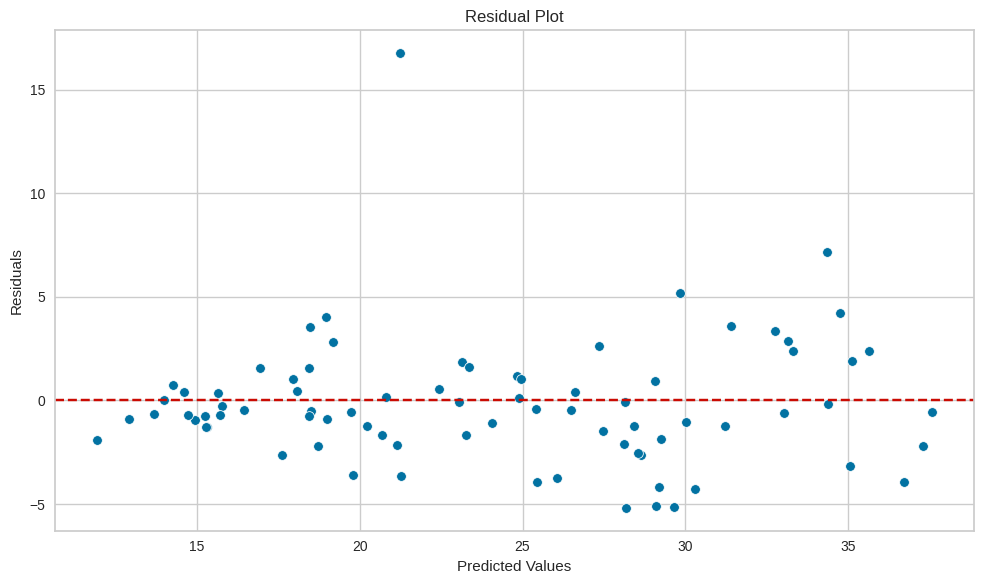

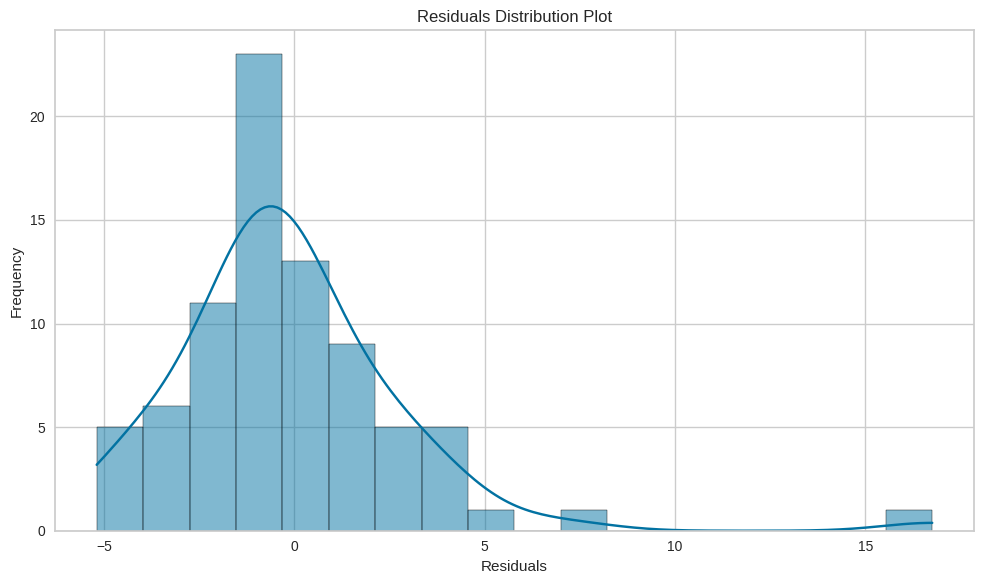

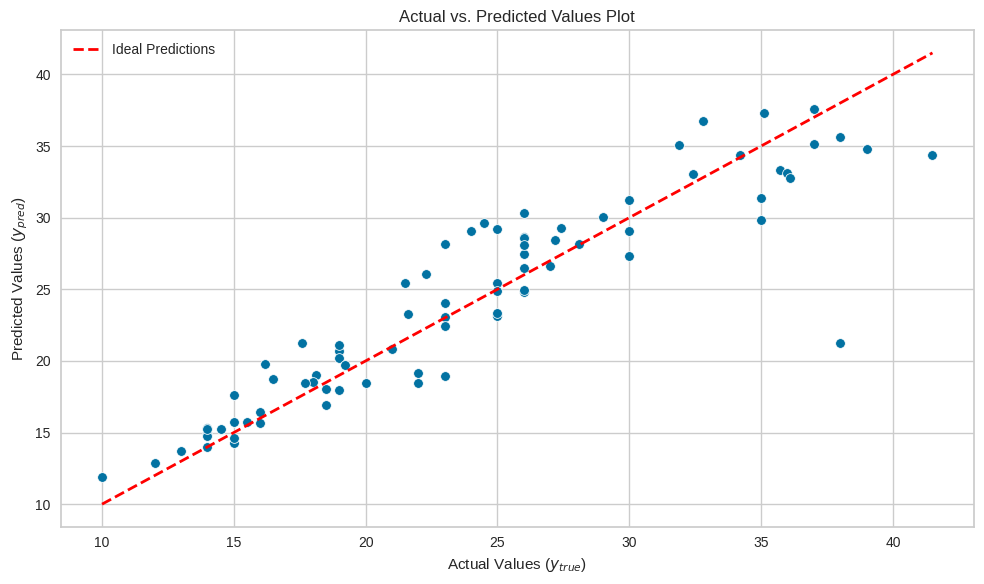

\ensemble2 model saved to best_ensemble2_model.pkl


In [83]:
model_evaluation(ensemble2, X_test, y_test, results_dir, name="ensemble2")

lgbm R²: 0.8251
lgbm MAE: 2.2135
lgbm MSE: 10.2002
lgbm RMSE: 3.1938


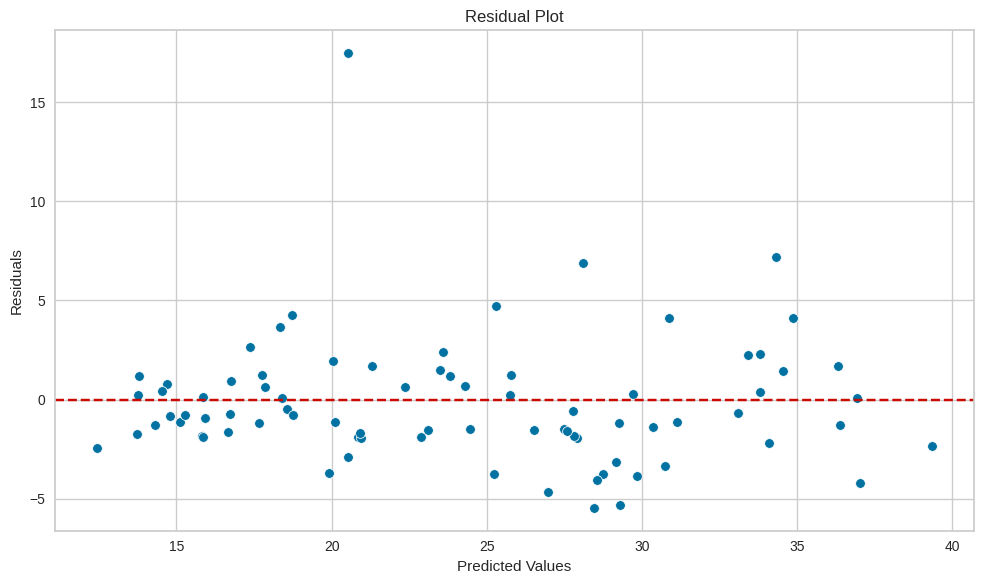

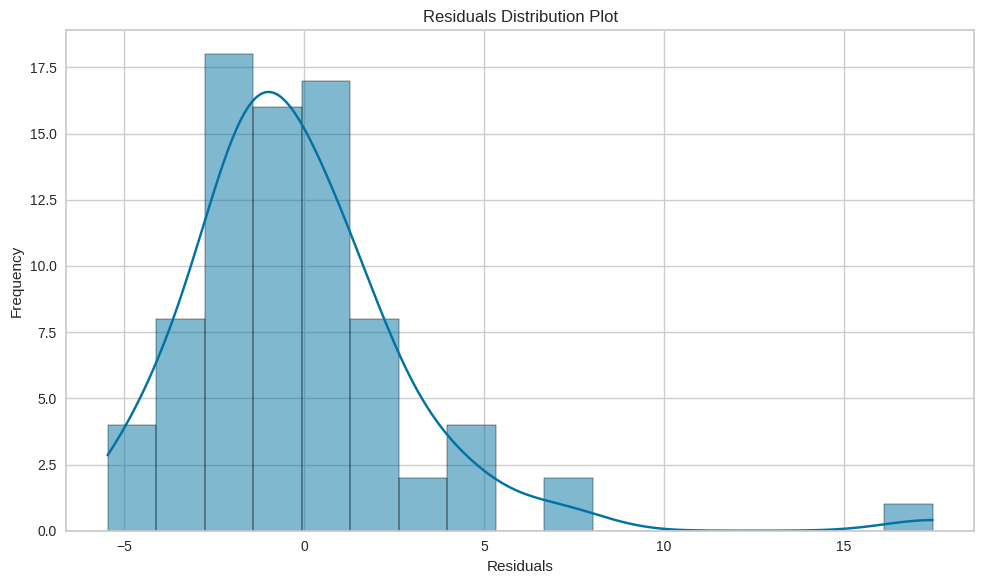

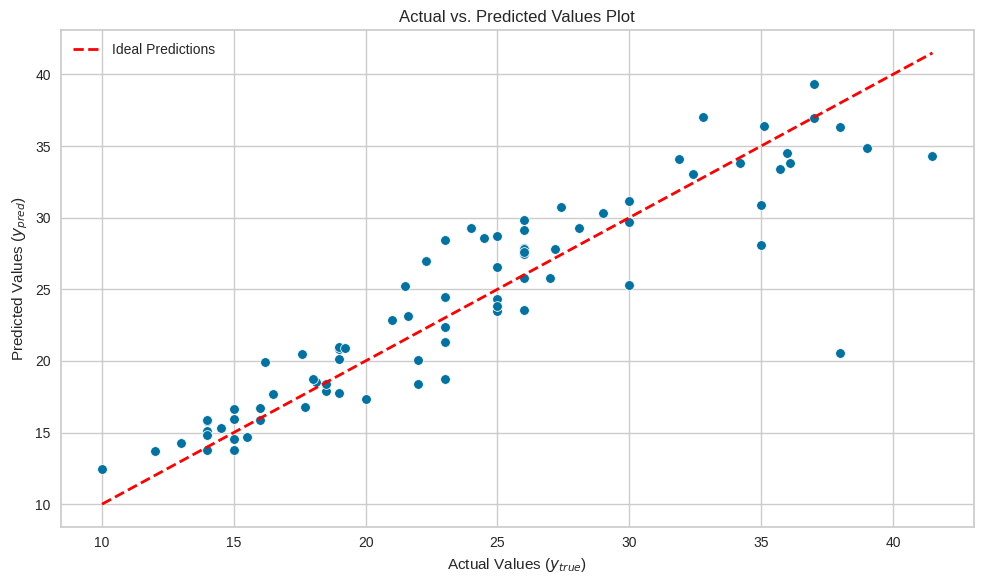

\lgbm model saved to best_lgbm_model.pkl


In [84]:
model_evaluation(best_lgbm, X_test, y_test, results_dir, name="lgbm")

catboost R²: 0.8400
catboost MAE: 2.1325
catboost MSE: 9.3303
catboost RMSE: 3.0545


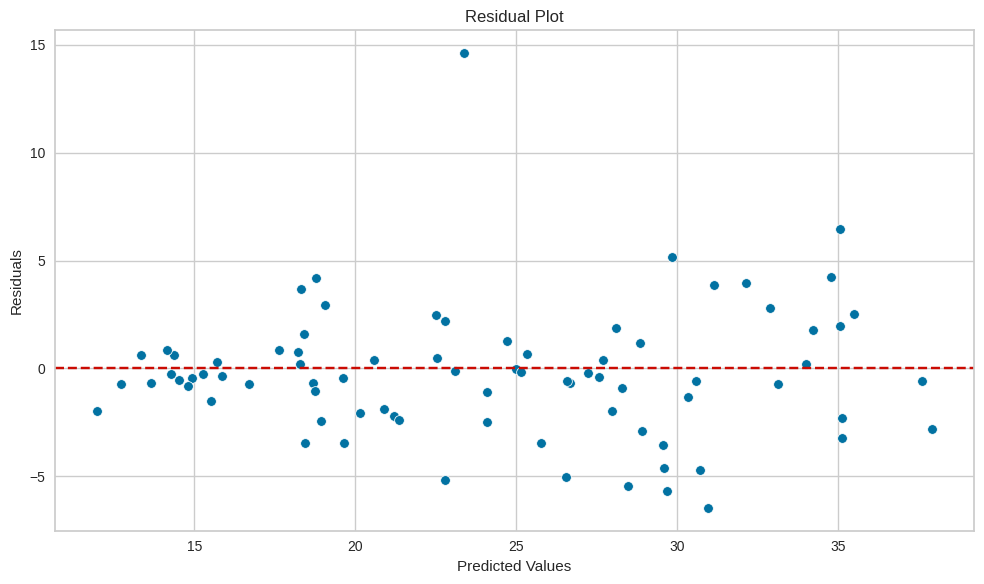

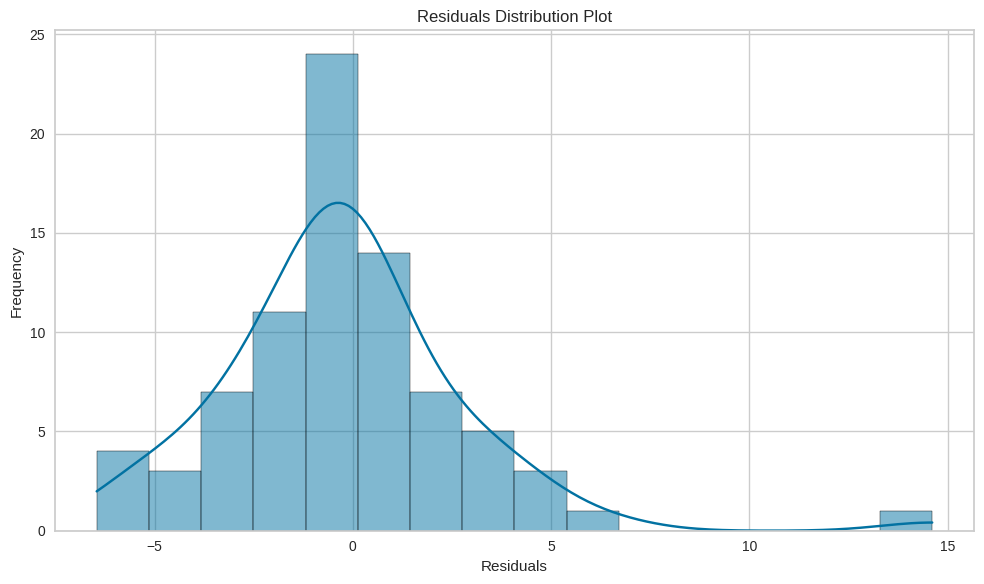

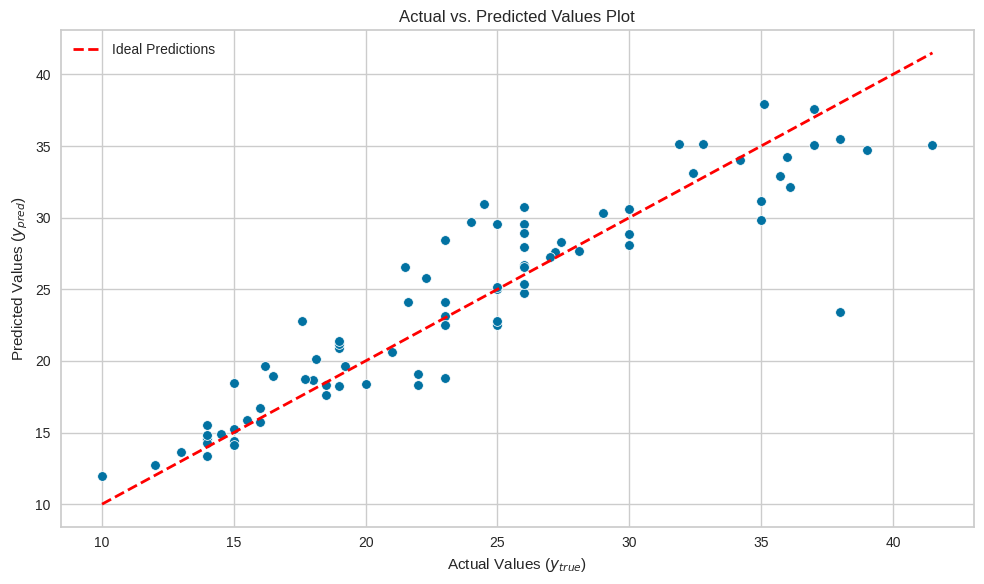

\catboost model saved to best_catboost_model.pkl


In [85]:
model_evaluation(best_catboost, X_test, y_test, results_dir, name="catboost")

et R²: 0.8281
et MAE: 2.0974
et MSE: 10.0263
et RMSE: 3.1664


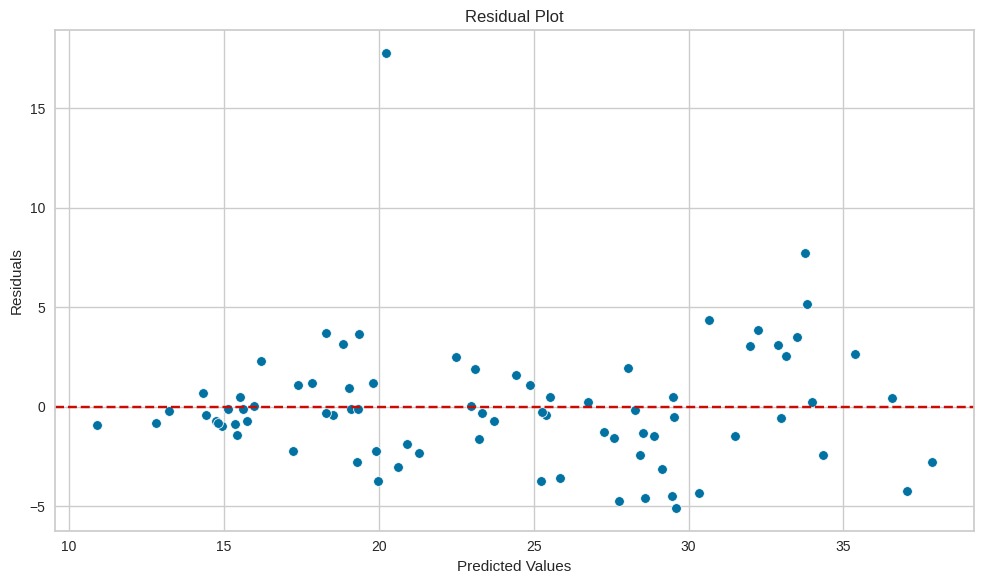

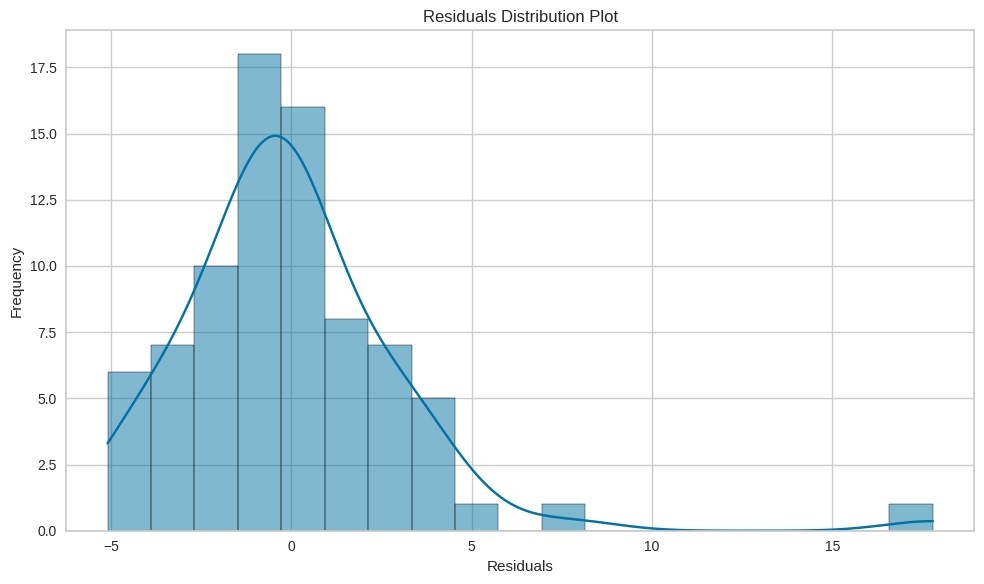

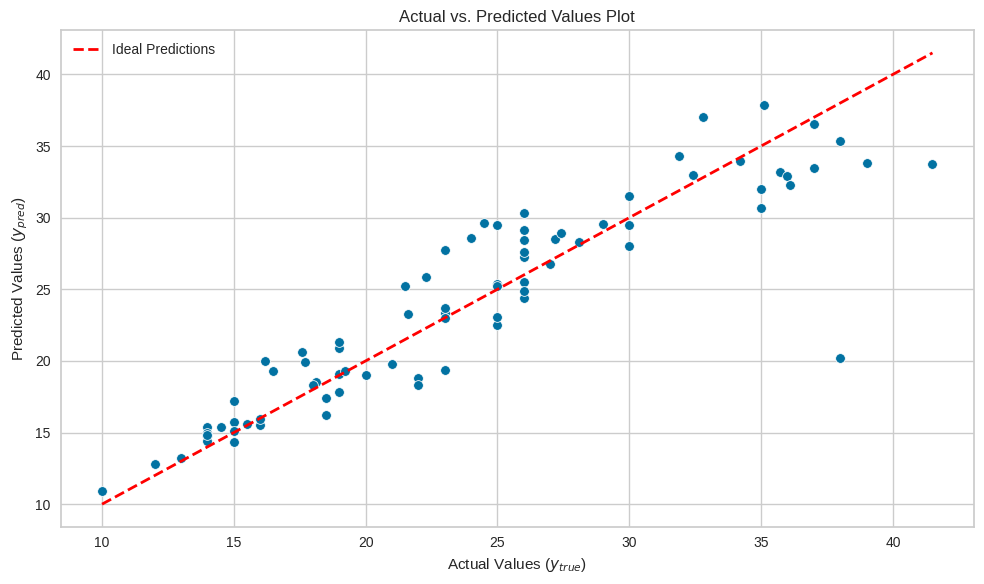

\et model saved to best_et_model.pkl


In [86]:
model_evaluation(best_et, X_test, y_test, results_dir, name="et")

In [87]:
X_train.shape

(318, 7)

In [88]:
X_test.shape

(80, 7)

In [89]:
import pickle

# Save scaler
with open("../results/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

### Optimisation using Bayesian Optimisation

In [90]:
best_model = ensemble1

In [91]:
#Define Objective Function
def objective_function(x):
    # Unpack variables
    cylinders, displacement, horsepower, weight, acceleration, model_year, origin = x
    
    # Round integer features
    cylinders = int(round(cylinders))
    model_year = int(round(model_year))
    origin = int(round(origin))
    
    # Create input
    X_input = np.array([[cylinders, displacement, horsepower, weight, acceleration, model_year, origin]])
    
    # Predict MPG
    mpg_pred = best_model.predict(X_input)[0]
    
    return -mpg_pred  # minimize negative MPG


In [92]:
# Define Bounds

bounds = [
    (X["cylinders"].min(), X["cylinders"].max()),
    (X["displacement"].min(), X["displacement"].max()),
    (X["horsepower"].min(), X["horsepower"].max()),
    (X["weight"].min(), X["weight"].max()),
    (X["acceleration"].min(), X["acceleration"].max()),
    (X["model_year"].min(), X["model_year"].max()),
    (X["origin"].min(), X["origin"].max())
]

In [93]:
# Run Bayesian Optimization

from skopt import gp_minimize

result = gp_minimize(
    func=objective_function,
    dimensions=bounds,
    n_calls=50,
    random_state=42
)

result

          fun: -19.913291633514987
            x: [5, 123.28945853579108, 147.86404601649548, 1811.9636392285827, 18.474783548375452, 81, 1]
    func_vals: [-1.984e+01 -1.991e+01 ... -1.991e+01 -1.991e+01]
      x_iters: [[7, 138.98926367820542, 168.02164154268843, 3718.09050707726, 14.774158888238123, 71, 2], [5, 123.28945853579108, 147.86404601649548, 1811.9636392285827, 18.474783548375452, 81, 1], [8, 306.96534422592634, 141.72371961641596, 1637.9228585099434, 9.109036495554971, 76, 2], [3, 444.8433857916448, 82.42871477734262, 1932.568894597259, 17.08637252506337, 75, 3], [5, 400.79693740695615, 152.46812978898754, 3201.9108616965786, 8.977750479542213, 81, 2], [5, 74.1789396092229, 82.13488370986633, 2463.0968186737437, 17.95573115226114, 77, 3], [4, 219.34045513084422, 74.51994773883176, 4277.159694190361, 14.497088718182681, 72, 2], [3, 393.9642077682645, 116.38652187236835, 3006.6948823783996, 21.217228801636843, 79, 2], [6, 269.5628586299938, 196.42342181067318, 4591.670884287

In [94]:
# Extract Optimal Values
best_x = result.x
best_mpg = -result.fun  # convert back

# Round integer features
best_x[0] = int(round(best_x[0]))  # cylinders
best_x[5] = int(round(best_x[5]))  # model_year
best_x[6] = int(round(best_x[6]))  # origin


In [95]:
print(best_x)

print("\n", best_mpg)

[5, 123.28945853579108, 147.86404601649548, 1811.9636392285827, 18.474783548375452, 81, 1]

 19.913291633514987


In [96]:
# Display Results (4 decimal places)
features = [
    "Cylinders",
    "Displacement",
    "Horsepower",
    "Weight",
    "Acceleration",
    "Model Year",
    "Origin"
]

print("\nOptimal Car Configuration (Max MPG):\n")

for name, value in zip(features, best_x):
    print(f"{name}: {value:.4f}")

print(f"\nMaximum MPG: {best_mpg:.4f}")



Optimal Car Configuration (Max MPG):

Cylinders: 5.0000
Displacement: 123.2895
Horsepower: 147.8640
Weight: 1811.9636
Acceleration: 18.4748
Model Year: 81.0000
Origin: 1.0000

Maximum MPG: 19.9133
